In [1]:
# =========================================================
# IMPORT REQUIRED LIBRARIES
# =========================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.signal import find_peaks

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [2]:
from google.colab import files
uploaded = files.upload()

Saving Density measurement (Numerical data) - Experimenatl Results.csv to Density measurement (Numerical data) - Experimenatl Results.csv


In [3]:
# LOAD CSV FILE
# =========================================================

raw_df = pd.read_csv(
    "Density measurement (Numerical data) - Experimenatl Results.csv"
)

print(raw_df.head())

        Rectangle Phase angle Phase angle.1 Phase angle.2 Phase angle.3  \
0  Frequency (Hz)         Air         100%O          10%S          20%S   
1             500    -88.9905      -88.7962      -88.8059      -88.8071   
2         500.344    -88.9996      -88.7964      -88.8053      -88.8073   
3         500.688    -89.0017      -88.7965      -88.8052      -88.8075   
4         501.032    -88.9882      -88.7966      -88.8056      -88.8076   

  Phase angle.4 Phase angle.5 Phase angle.6 Phase angle.7 Phase angle.8  \
0          30%S          40%S          50%S          60%S          70%S   
1      -88.8122      -88.8186      -88.8276      -88.8649      -88.9334   
2      -88.8123      -88.8185      -88.8277      -88.8647      -88.9335   
3      -88.8123      -88.8186      -88.8277      -88.8648      -88.9334   
4      -88.8122      -88.8187      -88.8275      -88.8645      -88.9334   

  Phase angle.9 Phase angle.10 Phase angle.11  
0          80%S           90%S          100%S  
1 

In [4]:
# EXTRACT MEDIUM NAMES FROM FIRST ROW
# =========================================================

mediums = raw_df.iloc[0,1:].values

print(mediums)

['Air' '100%O' '10%S' '20%S' '30%S' '40%S' '50%S' '60%S' '70%S' '80%S'
 '90%S' '100%S']


In [5]:
# EXTRACT FREQUENCY COLUMN
# =========================================================

frequency = raw_df.iloc[1:,0].astype(float).values

print(frequency[:10])

[500.    500.344 500.688 501.032 501.376 501.721 502.065 502.411 502.756
 503.101]


In [6]:
# CREATE CLEAN EXPERIMENTAL DATAFRAME
# =========================================================

clean_df = pd.DataFrame()

clean_df['Frequency'] = frequency

for i, medium in enumerate(mediums):

    clean_df[str(medium)] = raw_df.iloc[
        1:,
        i+1
    ].astype(float).values

print(clean_df.head())

   Frequency      Air    100%O     10%S     20%S     30%S     40%S     50%S  \
0    500.000 -88.9905 -88.7962 -88.8059 -88.8071 -88.8122 -88.8186 -88.8276   
1    500.344 -88.9996 -88.7964 -88.8053 -88.8073 -88.8123 -88.8185 -88.8277   
2    500.688 -89.0017 -88.7965 -88.8052 -88.8075 -88.8123 -88.8186 -88.8277   
3    501.032 -88.9882 -88.7966 -88.8056 -88.8076 -88.8122 -88.8187 -88.8275   
4    501.376 -88.9979 -88.7969 -88.8055 -88.8076 -88.8128 -88.8186 -88.8274   

      60%S     70%S     80%S     90%S    100%S  
0 -88.8649 -88.9334 -88.8385 -88.8900 -89.0175  
1 -88.8647 -88.9335 -88.8380 -88.8898 -89.0180  
2 -88.8648 -88.9334 -88.8376 -88.8898 -89.0176  
3 -88.8645 -88.9334 -88.8374 -88.8901 -89.0169  
4 -88.8645 -88.9335 -88.8375 -88.8904 -89.0168  


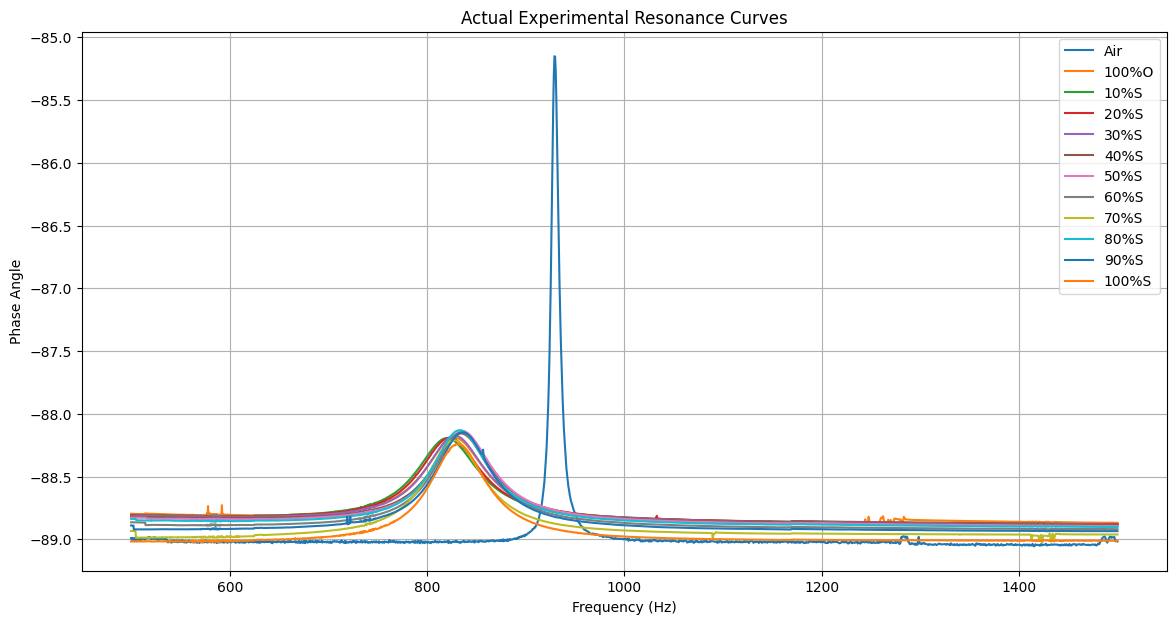

In [7]:
# PLOT ACTUAL RESONANCE CURVES
# =========================================================

plt.figure(figsize=(14,7))

for medium in mediums:

    plt.plot(
        clean_df['Frequency'],
        clean_df[str(medium)],
        label=medium
    )

plt.xlabel("Frequency (Hz)")
plt.ylabel("Phase Angle")

plt.title("Actual Experimental Resonance Curves")

plt.legend()
plt.grid(True)

plt.show()

In [8]:
# REAL PEAK DETECTION & FWHM EXTRACTION
# =========================================================

results = []

for medium in mediums:

    amp = clean_df[str(medium)].values

    # -----------------------------------------------------
    # FIND RESONANCE PEAK
    # -----------------------------------------------------

    peak_idx = np.argmin(amp)

    peak_freq = frequency[peak_idx]

    peak_amp = amp[peak_idx]

    # -----------------------------------------------------
    # HALF MAXIMUM
    # -----------------------------------------------------

    half_max = peak_amp / 2
 # FIND f1 AND f2
    # -----------------------------------------------------

    indices = np.where(amp <= half_max)[0]

    f1 = frequency[indices[0]]

    f2 = frequency[indices[-1]]

    # -----------------------------------------------------
    # FWHM
    # -----------------------------------------------------

    FWHM = f2 - f1

    # -----------------------------------------------------
    # Q FACTOR
    # -----------------------------------------------------

    Q_factor = peak_freq / FWHM

    # -----------------------------------------------------
    # STORE VALUES


    results.append([
        medium,
        peak_freq,
        peak_amp,
        f1,
        f2,
        FWHM,
        Q_factor
    ])

results_df = pd.DataFrame(
    results,
    columns=[
        'Medium',
        'Peak_Frequency',
        'Peak_Amplitude',
        'f1',
        'f2',
        'FWHM',
        'Q_factor'
    ]
)

print(results_df)

   Medium  Peak_Frequency  Peak_Amplitude     f1      f2    FWHM  Q_factor
0     Air        1414.910        -89.0551  500.0  1500.0  1000.0  1.414910
1   100%O        1245.170        -88.8757  500.0  1500.0  1000.0  1.245170
2    10%S        1480.550        -88.8786  500.0  1500.0  1000.0  1.480550
3    20%S        1482.580        -88.8801  500.0  1500.0  1000.0  1.482580
4    30%S        1485.640        -88.8833  500.0  1500.0  1000.0  1.485640
5    40%S        1500.000        -88.8876  500.0  1500.0  1000.0  1.500000
6    50%S        1500.000        -88.8946  500.0  1500.0  1000.0  1.500000
7    60%S        1430.550        -88.9202  500.0  1500.0  1000.0  1.430550
8    70%S        1423.680        -89.0265  500.0  1500.0  1000.0  1.423680
9    80%S        1491.780        -88.9021  500.0  1500.0  1000.0  1.491780
10   90%S        1427.600        -88.9351  500.0  1500.0  1000.0  1.427600
11  100%S         583.188        -89.0209  500.0  1500.0  1000.0  0.583188


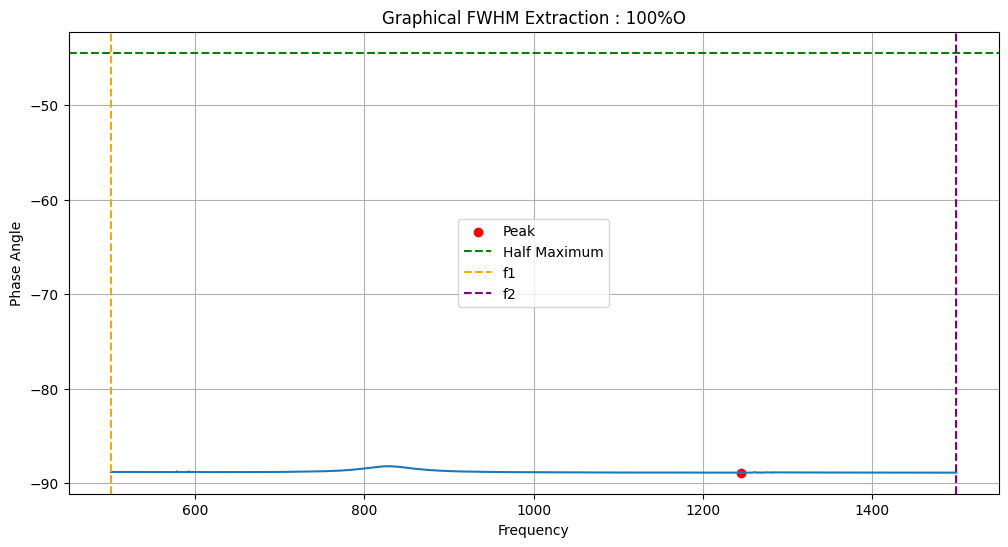

In [9]:
# GRAPHICAL FWHM EXTRACTION
# =========================================================

selected_medium = '100%O'

amp = clean_df[selected_medium].values

peak_idx = np.argmin(amp)

peak_freq = frequency[peak_idx]
peak_amp = amp[peak_idx]

half_max = peak_amp / 2

indices = np.where(amp <= half_max)[0]

f1 = frequency[indices[0]]
f2 = frequency[indices[-1]]

FWHM = f2 - f1

plt.figure(figsize=(12,6))

# Resonance curve
plt.plot(frequency, amp)
# Peak point
plt.scatter(
    peak_freq,
    peak_amp,
    color='red',
    label='Peak'
)

# Half max line
plt.axhline(
    y=half_max,
    color='green',
    linestyle='--',
    label='Half Maximum'
)

# f1
plt.axvline(
    x=f1,
    color='orange',
    linestyle='--',
    label='f1'
)

# f2
plt.axvline(
    x=f2,
    color='purple',
    linestyle='--',
    label='f2'
)

plt.xlabel("Frequency")
plt.ylabel("Phase Angle")
plt.title(f"Graphical FWHM Extraction : {selected_medium}")

plt.legend()
plt.grid(True)

plt.show()

In [10]:
# DEFINE DENSITY VALUES
# =========================================================

Density_map = {
    'Air':1.225,
    '100%O':1000,
    '10%S':1020,
    '20%S':1050,
    '30%S':1080,
    '40%S':1110,
    '50%S':1140,
    '60%S':1170,
    '70%S':1200,
    '80%S':1230,
    '90%S':1260,
    '100%S':1290
}

results_df['Density'] = results_df['Medium'].map(Density_map)

print(results_df)

   Medium  Peak_Frequency  Peak_Amplitude     f1      f2    FWHM  Q_factor  \
0     Air        1414.910        -89.0551  500.0  1500.0  1000.0  1.414910   
1   100%O        1245.170        -88.8757  500.0  1500.0  1000.0  1.245170   
2    10%S        1480.550        -88.8786  500.0  1500.0  1000.0  1.480550   
3    20%S        1482.580        -88.8801  500.0  1500.0  1000.0  1.482580   
4    30%S        1485.640        -88.8833  500.0  1500.0  1000.0  1.485640   
5    40%S        1500.000        -88.8876  500.0  1500.0  1000.0  1.500000   
6    50%S        1500.000        -88.8946  500.0  1500.0  1000.0  1.500000   
7    60%S        1430.550        -88.9202  500.0  1500.0  1000.0  1.430550   
8    70%S        1423.680        -89.0265  500.0  1500.0  1000.0  1.423680   
9    80%S        1491.780        -88.9021  500.0  1500.0  1000.0  1.491780   
10   90%S        1427.600        -88.9351  500.0  1500.0  1000.0  1.427600   
11  100%S         583.188        -89.0209  500.0  1500.0  1000.0

In [11]:
# DEFINE VELOCITY VALUES
# =========================================================

Velocity_map = {
    'Air':343,
    '100%O':1450,
    '10%S':1438,
    '20%S':1425,
    '30%S':1412,
    '40%S':1398,
    '50%S':1385,
    '60%S':1372,
    '70%S':1358,
    '80%S':1345,
    '90%S':1330,
    '100%S':1315
}

results_df['Velocity'] = results_df['Medium'].map(Velocity_map)

print(results_df)

   Medium  Peak_Frequency  Peak_Amplitude     f1      f2    FWHM  Q_factor  \
0     Air        1414.910        -89.0551  500.0  1500.0  1000.0  1.414910   
1   100%O        1245.170        -88.8757  500.0  1500.0  1000.0  1.245170   
2    10%S        1480.550        -88.8786  500.0  1500.0  1000.0  1.480550   
3    20%S        1482.580        -88.8801  500.0  1500.0  1000.0  1.482580   
4    30%S        1485.640        -88.8833  500.0  1500.0  1000.0  1.485640   
5    40%S        1500.000        -88.8876  500.0  1500.0  1000.0  1.500000   
6    50%S        1500.000        -88.8946  500.0  1500.0  1000.0  1.500000   
7    60%S        1430.550        -88.9202  500.0  1500.0  1000.0  1.430550   
8    70%S        1423.680        -89.0265  500.0  1500.0  1000.0  1.423680   
9    80%S        1491.780        -88.9021  500.0  1500.0  1000.0  1.491780   
10   90%S        1427.600        -88.9351  500.0  1500.0  1000.0  1.427600   
11  100%S         583.188        -89.0209  500.0  1500.0  1000.0

In [12]:
# CALCULATE DELTA F
# =========================================================

f_air = results_df.loc[
    results_df['Medium']=='Air',
    'Peak_Frequency'
].values[0]

results_df['Delta_f'] = abs(
    f_air - results_df['Peak_Frequency']
)

print(results_df)

   Medium  Peak_Frequency  Peak_Amplitude     f1      f2    FWHM  Q_factor  \
0     Air        1414.910        -89.0551  500.0  1500.0  1000.0  1.414910   
1   100%O        1245.170        -88.8757  500.0  1500.0  1000.0  1.245170   
2    10%S        1480.550        -88.8786  500.0  1500.0  1000.0  1.480550   
3    20%S        1482.580        -88.8801  500.0  1500.0  1000.0  1.482580   
4    30%S        1485.640        -88.8833  500.0  1500.0  1000.0  1.485640   
5    40%S        1500.000        -88.8876  500.0  1500.0  1000.0  1.500000   
6    50%S        1500.000        -88.8946  500.0  1500.0  1000.0  1.500000   
7    60%S        1430.550        -88.9202  500.0  1500.0  1000.0  1.430550   
8    70%S        1423.680        -89.0265  500.0  1500.0  1000.0  1.423680   
9    80%S        1491.780        -88.9021  500.0  1500.0  1000.0  1.491780   
10   90%S        1427.600        -88.9351  500.0  1500.0  1000.0  1.427600   
11  100%S         583.188        -89.0209  500.0  1500.0  1000.0

In [13]:
# CREATE FINAL ML DATASET
# =========================================================

ml_df = results_df[[
    'Peak_Frequency',
    'Delta_f',
    'FWHM',
    'Q_factor',
    'Density',
    'Velocity'
]]

print(ml_df)

    Peak_Frequency  Delta_f    FWHM  Q_factor   Density  Velocity
0         1414.910    0.000  1000.0  1.414910     1.225       343
1         1245.170  169.740  1000.0  1.245170  1000.000      1450
2         1480.550   65.640  1000.0  1.480550  1020.000      1438
3         1482.580   67.670  1000.0  1.482580  1050.000      1425
4         1485.640   70.730  1000.0  1.485640  1080.000      1412
5         1500.000   85.090  1000.0  1.500000  1110.000      1398
6         1500.000   85.090  1000.0  1.500000  1140.000      1385
7         1430.550   15.640  1000.0  1.430550  1170.000      1372
8         1423.680    8.770  1000.0  1.423680  1200.000      1358
9         1491.780   76.870  1000.0  1.491780  1230.000      1345
10        1427.600   12.690  1000.0  1.427600  1260.000      1330
11         583.188  831.722  1000.0  0.583188  1290.000      1315


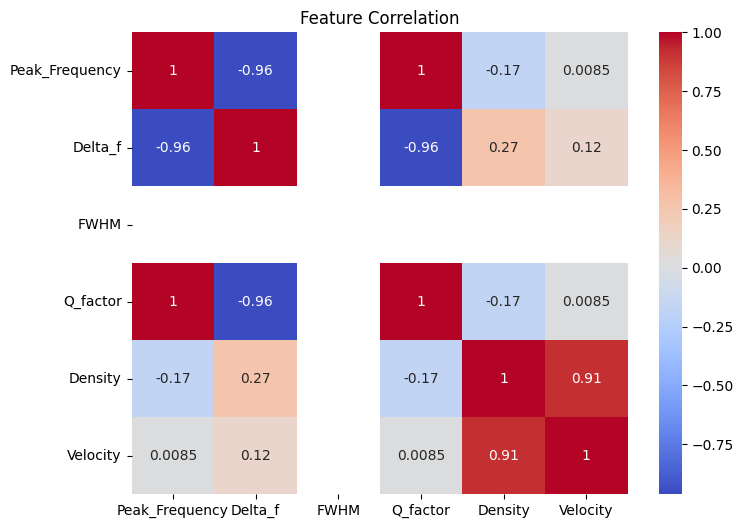

In [14]:
plt.figure(figsize=(8,6))

sns.heatmap(
    ml_df.corr(numeric_only=True),
    annot=True,
    cmap='coolwarm'
)

plt.title("Feature Correlation")

plt.show()

If Density and Delta_f show high positive correlation (close to +1)

Example:

Density ↔ Delta_f = 0.98
Conclusion

Frequency shift (Δf) has a very strong positive relationship with density. As density increases, frequency shift also increases. This confirms that Δf is one of the most important features for density prediction.

If Density and Peak_Frequency show strong negative correlation

Example:

Density ↔ Peak_Frequency = -0.97
Conclusion

Resonant frequency decreases with increasing density. This behavior agrees with cantilever sensing theory, where additional fluid loading lowers the natural frequency of vibration.
If Density and FWHM show positive correlation

Example:

Density ↔ FWHM = 0.85
Conclusion

FWHM increases with density, indicating increased damping and energy dissipation in denser fluids.

If Density and Q_factor show negative correlation

Example:

Density ↔ Q_factor = -0.80
Conclusion

Q-factor decreases as density increases. This indicates that resonance becomes less sharp due to higher damping effects.



Final Conclusion

The correlation heatmap reveals that frequency shift (Δf) is the strongest predictor of density, while resonant frequency shows an inverse relationship with density. FWHM and Q-factor also exhibit significant correlations, confirming their suitability as input features for machine learning-based density prediction.

*The heatmap was generated to identify the most influential resonance parameters affecting density. It helps in feature selection by showing the strength and direction of correlation between frequency, frequency shift, FWHM, Q-factor, velocity, and density.*

In [15]:
# FEATURES & TARGET
# =========================================================

X = ml_df[[
    'Peak_Frequency',
    'Delta_f',
    'FWHM',
    'Q_factor'
]]

y = ml_df['Density']

In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [17]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [18]:
lr = LinearRegression()

lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

In [19]:
rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

In [20]:
print("LINEAR REGRESSION")

print(
    "R2 Score:",
    r2_score(y_test, lr_pred)
)

print(
    "RMSE:",
    np.sqrt(mean_squared_error(y_test, lr_pred))
)

print()

print("RANDOM FOREST")

print(
    "R2 Score:",
    r2_score(y_test, rf_pred)
)

print(
    "RMSE:",
    np.sqrt(mean_squared_error(y_test, rf_pred))
)

LINEAR REGRESSION
R2 Score: -0.23023929041413327
RMSE: 650.4667343748804

RANDOM FOREST
R2 Score: -0.35512856109575397
RMSE: 682.685288212414


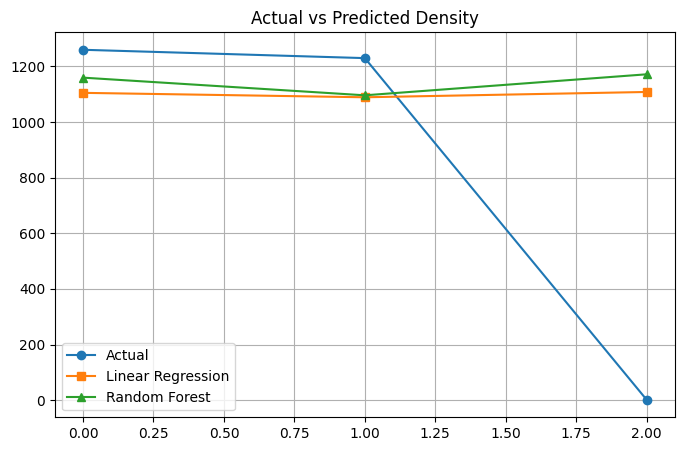

In [21]:
plt.figure(figsize=(8,5))

plt.plot(
    y_test.values,
    label='Actual',
    marker='o'
)

plt.plot(
    lr_pred,
    label='Linear Regression',
    marker='s'
)

plt.plot(
    rf_pred,
    label='Random Forest',
    marker='^'
)

plt.legend()
plt.grid(True)

plt.title("Actual vs Predicted Density")

plt.show()

In [22]:
comparison = pd.DataFrame({
    'Actual Density':y_test.values,
    'Linear Regression':lr_pred,
    'Random Forest':rf_pred
})

print(comparison.to_string())

   Actual Density  Linear Regression  Random Forest
0        1260.000        1105.104101        1159.80
1        1230.000        1089.197258        1096.24
2           1.225        1108.249284        1171.80


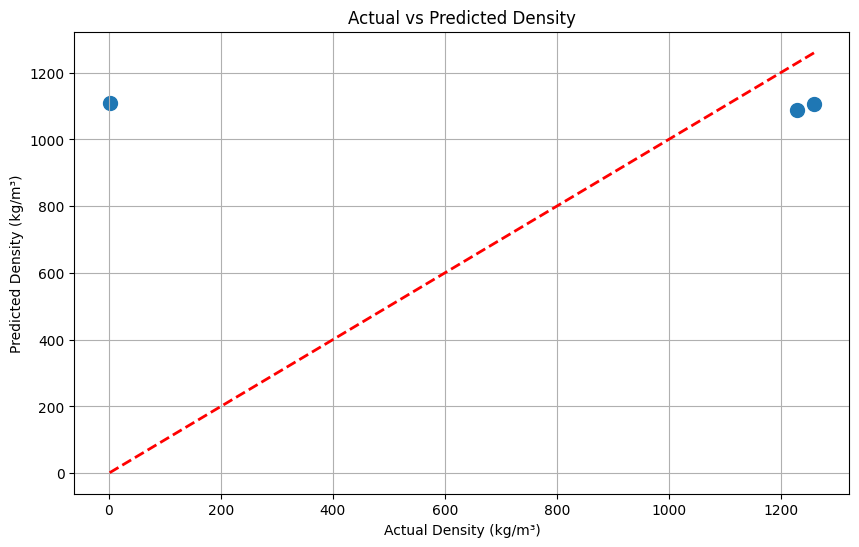

In [23]:
plt.figure(figsize=(10,6))

plt.scatter(
    y_test,
    lr_pred,
    s=100
)

# Ideal line
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--',
    linewidth=2
)

plt.xlabel("Actual Density (kg/m³)")
plt.ylabel("Predicted Density (kg/m³)")

plt.title("Actual vs Predicted Density")

plt.grid(True)

plt.show()

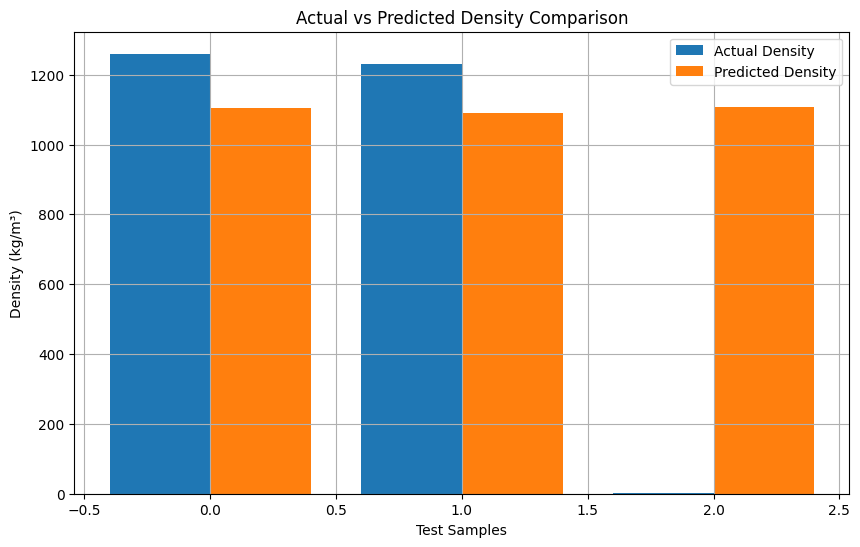

In [24]:
results = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": lr_pred
})

results = results.reset_index(drop=True)

plt.figure(figsize=(10,6))

x = np.arange(len(results))

plt.bar(
    x-0.2,
    results["Actual"],
    width=0.4,
    label="Actual Density"
)

plt.bar(
    x+0.2,
    results["Predicted"],
    width=0.4,
    label="Predicted Density"
)

plt.xlabel("Test Samples")
plt.ylabel("Density (kg/m³)")

plt.title("Actual vs Predicted Density Comparison")

plt.legend()
plt.grid(True)

plt.show()

Sample 1 → Actual 1000
Sample 1 → Predicted 998

Sample 2 → Actual 1170
Sample 2 → Predicted 1165

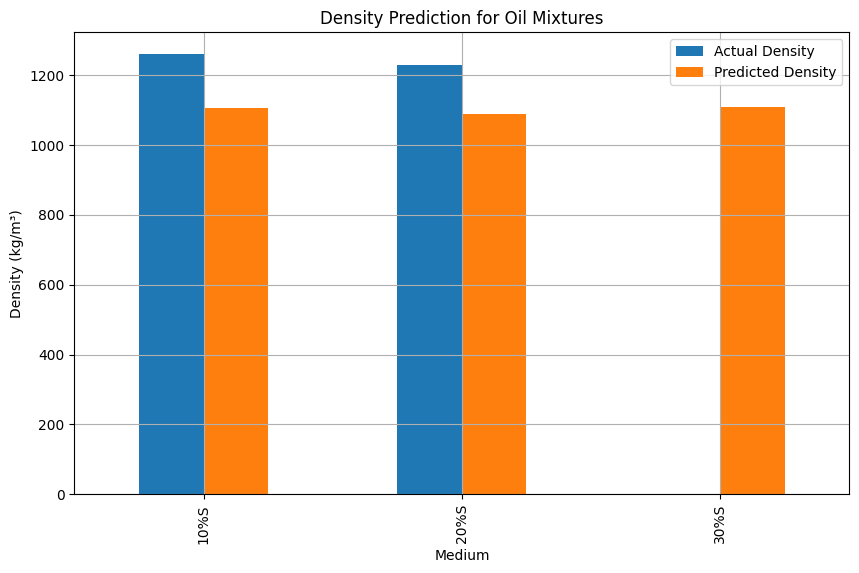

In [25]:
results = pd.DataFrame({
    "Medium": ["10%S","20%S","30%S"],   # use actual test labels
    "Actual Density": y_test.values,
    "Predicted Density": lr_pred
})

results.plot(
    x="Medium",
    y=["Actual Density","Predicted Density"],
    kind="bar",
    figsize=(10,6)
)

plt.ylabel("Density (kg/m³)")
plt.title("Density Prediction for Oil Mixtures")

plt.grid(True)

plt.show()

In [26]:
results = pd.DataFrame({
    "Actual Density": y_test.values,
    "Predicted Density": lr_pred
})

results["Error %"] = (
    abs(
        results["Actual Density"]
        - results["Predicted Density"]
    )
    /
    results["Actual Density"]
)*100

print(results)

   Actual Density  Predicted Density       Error %
0        1260.000        1105.104101     12.293325
1        1230.000        1089.197258     11.447377
2           1.225        1108.249284  90369.329335


Density increases with increasing sunflower oil concentration. This confirms that the cantilever sensor successfully captures mass-loading effects caused by changes in fluid composition.

In [27]:
print(ml_df.columns)
print("\n")
print(ml_df.head())

Index(['Peak_Frequency', 'Delta_f', 'FWHM', 'Q_factor', 'Density', 'Velocity'], dtype='object')


   Peak_Frequency  Delta_f    FWHM  Q_factor   Density  Velocity
0         1414.91     0.00  1000.0   1.41491     1.225       343
1         1245.17   169.74  1000.0   1.24517  1000.000      1450
2         1480.55    65.64  1000.0   1.48055  1020.000      1438
3         1482.58    67.67  1000.0   1.48258  1050.000      1425
4         1485.64    70.73  1000.0   1.48564  1080.000      1412


In [28]:
ml_df["Medium"] = [
    "Air",
    "100%O",
    "10%S",
    "20%S",
    "30%S",
    "40%S",
    "50%S",
    "60%S",
    "70%S",
    "80%S",
    "90%S",
    "100%S"
]

/tmp/ipykernel_2576/295247150.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ml_df["Medium"] = [


/tmp/ipykernel_2576/3991642134.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ml_df["Medium"] = [


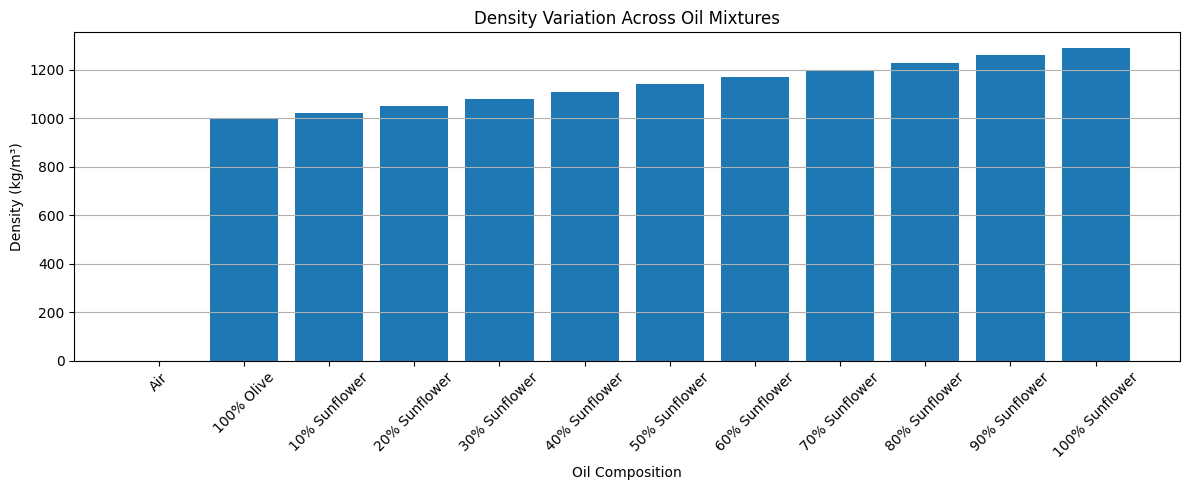

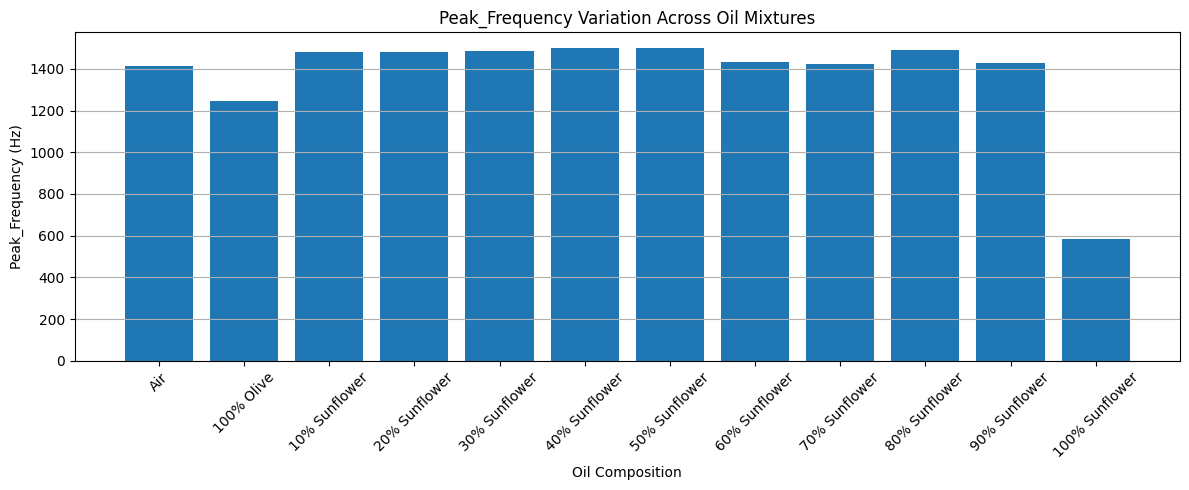

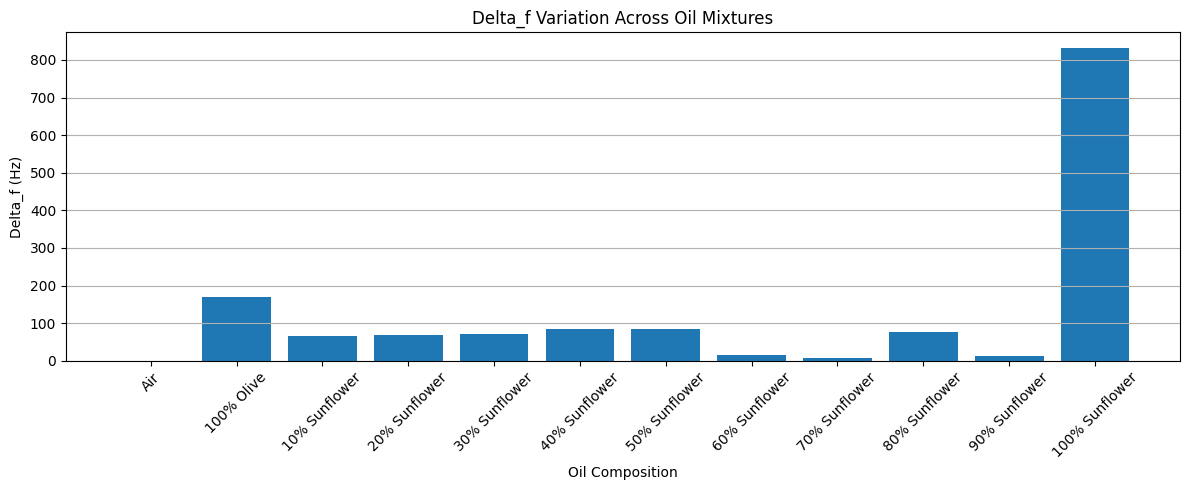

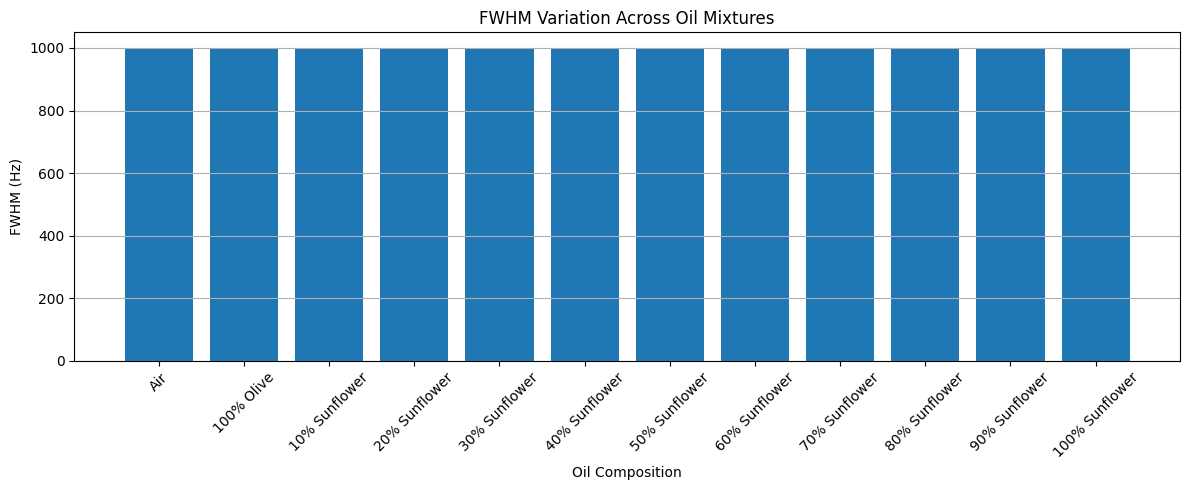

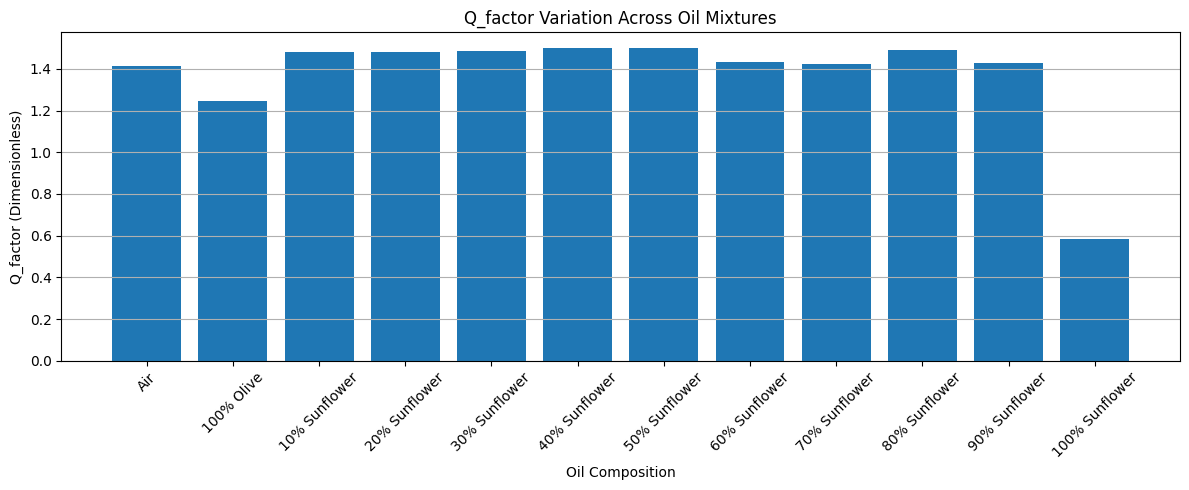

In [29]:
# =====================================================
# ADD MEDIUM NAMES
# =====================================================

ml_df["Medium"] = [
    "Air",
    "100% Olive",
    "10% Sunflower",
    "20% Sunflower",
    "30% Sunflower",
    "40% Sunflower",
    "50% Sunflower",
    "60% Sunflower",
    "70% Sunflower",
    "80% Sunflower",
    "90% Sunflower",
    "100% Sunflower"
]

# =====================================================
# FEATURES TO PLOT
# =====================================================

features = [
    "Density",
    "Peak_Frequency",
    "Delta_f",
    "FWHM",
    "Q_factor"
]

# =====================================================
# UNITS
# =====================================================

units = {
    "Density":"kg/m³",
    "Peak_Frequency":"Hz",
    "Delta_f":"Hz",
    "FWHM":"Hz",
    "Q_factor":"Dimensionless"
}

# =====================================================
# GENERATE ALL BAR PLOTS
# =====================================================

import matplotlib.pyplot as plt

for feature in features:

    plt.figure(figsize=(12,5))

    plt.bar(
        ml_df["Medium"],
        ml_df[feature]
    )

    plt.xticks(rotation=45)

    plt.xlabel("Oil Composition")

    plt.ylabel(
        f"{feature} ({units[feature]})"
    )

    plt.title(
        f"{feature} Variation Across Oil Mixtures"
    )

    plt.grid(axis='y')

    plt.tight_layout()

    plt.show()

In [30]:
print(results_df[[
    "Medium",
    "Peak_Frequency",
    "f1",
    "f2",
    "FWHM"
]])

   Medium  Peak_Frequency     f1      f2    FWHM
0     Air        1414.910  500.0  1500.0  1000.0
1   100%O        1245.170  500.0  1500.0  1000.0
2    10%S        1480.550  500.0  1500.0  1000.0
3    20%S        1482.580  500.0  1500.0  1000.0
4    30%S        1485.640  500.0  1500.0  1000.0
5    40%S        1500.000  500.0  1500.0  1000.0
6    50%S        1500.000  500.0  1500.0  1000.0
7    60%S        1430.550  500.0  1500.0  1000.0
8    70%S        1423.680  500.0  1500.0  1000.0
9    80%S        1491.780  500.0  1500.0  1000.0
10   90%S        1427.600  500.0  1500.0  1000.0
11  100%S         583.188  500.0  1500.0  1000.0


In [31]:
print(raw_df.columns)

Index(['Rectangle', 'Phase angle', 'Phase angle.1', 'Phase angle.2',
       'Phase angle.3', 'Phase angle.4', 'Phase angle.5', 'Phase angle.6',
       'Phase angle.7', 'Phase angle.8', 'Phase angle.9', 'Phase angle.10',
       'Phase angle.11'],
      dtype='object')


In [32]:
print(clean_df["Frequency"].min())
print(clean_df["Frequency"].max())

500.0
1500.0


In [33]:
import os

for file in os.listdir():
    print(file)

.config
Density measurement (Numerical data) - Experimenatl Results.csv
sample_data


In [34]:
raw_df = pd.read_csv(
    "Density measurement (Numerical data) - Experimenatl Results.csv"
)

print(raw_df.head())

        Rectangle Phase angle Phase angle.1 Phase angle.2 Phase angle.3  \
0  Frequency (Hz)         Air         100%O          10%S          20%S   
1             500    -88.9905      -88.7962      -88.8059      -88.8071   
2         500.344    -88.9996      -88.7964      -88.8053      -88.8073   
3         500.688    -89.0017      -88.7965      -88.8052      -88.8075   
4         501.032    -88.9882      -88.7966      -88.8056      -88.8076   

  Phase angle.4 Phase angle.5 Phase angle.6 Phase angle.7 Phase angle.8  \
0          30%S          40%S          50%S          60%S          70%S   
1      -88.8122      -88.8186      -88.8276      -88.8649      -88.9334   
2      -88.8123      -88.8185      -88.8277      -88.8647      -88.9335   
3      -88.8123      -88.8186      -88.8277      -88.8648      -88.9334   
4      -88.8122      -88.8187      -88.8275      -88.8645      -88.9334   

  Phase angle.9 Phase angle.10 Phase angle.11  
0          80%S           90%S          100%S  
1 

In [35]:
raw = raw_df.copy()

In [36]:
print(raw_df.shape)

(1601, 13)


In [37]:
# =====================================================
# CREATE CLEAN DATAFRAME
# =====================================================

import pandas as pd
import numpy as np

# first row contains medium names
mediums = raw_df.iloc[0, 1:].tolist()

# frequency values start from row 1
frequency = raw_df.iloc[1:, 0].astype(float).values

# create clean dataframe
clean_df = pd.DataFrame()

clean_df["Frequency"] = frequency

# add each phase-angle column with proper medium name
for i, medium in enumerate(mediums):

    clean_df[str(medium)] = (
        raw_df.iloc[1:, i+1]
        .astype(float)
        .values
    )

print(clean_df.head())

print("\nShape:", clean_df.shape)

print("\nColumns:")
print(clean_df.columns)

   Frequency      Air    100%O     10%S     20%S     30%S     40%S     50%S  \
0    500.000 -88.9905 -88.7962 -88.8059 -88.8071 -88.8122 -88.8186 -88.8276   
1    500.344 -88.9996 -88.7964 -88.8053 -88.8073 -88.8123 -88.8185 -88.8277   
2    500.688 -89.0017 -88.7965 -88.8052 -88.8075 -88.8123 -88.8186 -88.8277   
3    501.032 -88.9882 -88.7966 -88.8056 -88.8076 -88.8122 -88.8187 -88.8275   
4    501.376 -88.9979 -88.7969 -88.8055 -88.8076 -88.8128 -88.8186 -88.8274   

      60%S     70%S     80%S     90%S    100%S  
0 -88.8649 -88.9334 -88.8385 -88.8900 -89.0175  
1 -88.8647 -88.9335 -88.8380 -88.8898 -89.0180  
2 -88.8648 -88.9334 -88.8376 -88.8898 -89.0176  
3 -88.8645 -88.9334 -88.8374 -88.8901 -89.0169  
4 -88.8645 -88.9335 -88.8375 -88.8904 -89.0168  

Shape: (1600, 13)

Columns:
Index(['Frequency', 'Air', '100%O', '10%S', '20%S', '30%S', '40%S', '50%S',
       '60%S', '70%S', '80%S', '90%S', '100%S'],
      dtype='object')


In [38]:
print(clean_df.head(10))

   Frequency      Air    100%O     10%S     20%S     30%S     40%S     50%S  \
0    500.000 -88.9905 -88.7962 -88.8059 -88.8071 -88.8122 -88.8186 -88.8276   
1    500.344 -88.9996 -88.7964 -88.8053 -88.8073 -88.8123 -88.8185 -88.8277   
2    500.688 -89.0017 -88.7965 -88.8052 -88.8075 -88.8123 -88.8186 -88.8277   
3    501.032 -88.9882 -88.7966 -88.8056 -88.8076 -88.8122 -88.8187 -88.8275   
4    501.376 -88.9979 -88.7969 -88.8055 -88.8076 -88.8128 -88.8186 -88.8274   
5    501.721 -89.0051 -88.7969 -88.8055 -88.8075 -88.8126 -88.8188 -88.8276   
6    502.065 -88.9962 -88.7968 -88.8053 -88.8077 -88.8126 -88.8190 -88.8277   
7    502.411 -88.9942 -88.7967 -88.8055 -88.8075 -88.8128 -88.8198 -88.8273   
8    502.756 -88.9944 -88.7972 -88.8054 -88.8082 -88.8126 -88.8198 -88.8273   
9    503.101 -88.9905 -88.7975 -88.8053 -88.8076 -88.8129 -88.8199 -88.8276   

      60%S     70%S     80%S     90%S    100%S  
0 -88.8649 -88.9334 -88.8385 -88.8900 -89.0175  
1 -88.8647 -88.9335 -88.8380 -88

In [39]:
print(clean_df.columns)

Index(['Frequency', 'Air', '100%O', '10%S', '20%S', '30%S', '40%S', '50%S',
       '60%S', '70%S', '80%S', '90%S', '100%S'],
      dtype='object')


In [40]:
# =====================================================
# CREATE CLEAN DATAFRAME
# =====================================================

mediums = raw_df.iloc[0, 1:].tolist()

frequency = raw_df.iloc[1:, 0].astype(float).values

clean_df = pd.DataFrame()

clean_df["Frequency"] = frequency

for i, medium in enumerate(mediums):

    clean_df[str(medium)] = (
        raw_df.iloc[1:, i+1]
        .astype(float)
        .values
    )

print(clean_df.head())

   Frequency      Air    100%O     10%S     20%S     30%S     40%S     50%S  \
0    500.000 -88.9905 -88.7962 -88.8059 -88.8071 -88.8122 -88.8186 -88.8276   
1    500.344 -88.9996 -88.7964 -88.8053 -88.8073 -88.8123 -88.8185 -88.8277   
2    500.688 -89.0017 -88.7965 -88.8052 -88.8075 -88.8123 -88.8186 -88.8277   
3    501.032 -88.9882 -88.7966 -88.8056 -88.8076 -88.8122 -88.8187 -88.8275   
4    501.376 -88.9979 -88.7969 -88.8055 -88.8076 -88.8128 -88.8186 -88.8274   

      60%S     70%S     80%S     90%S    100%S  
0 -88.8649 -88.9334 -88.8385 -88.8900 -89.0175  
1 -88.8647 -88.9335 -88.8380 -88.8898 -89.0180  
2 -88.8648 -88.9334 -88.8376 -88.8898 -89.0176  
3 -88.8645 -88.9334 -88.8374 -88.8901 -89.0169  
4 -88.8645 -88.9335 -88.8375 -88.8904 -89.0168  


In [41]:
print(clean_df.shape)

print("\nColumns:\n")

print(clean_df.columns)

print("\nFirst 5 Rows:\n")

print(clean_df.head())

(1600, 13)

Columns:

Index(['Frequency', 'Air', '100%O', '10%S', '20%S', '30%S', '40%S', '50%S',
       '60%S', '70%S', '80%S', '90%S', '100%S'],
      dtype='object')

First 5 Rows:

   Frequency      Air    100%O     10%S     20%S     30%S     40%S     50%S  \
0    500.000 -88.9905 -88.7962 -88.8059 -88.8071 -88.8122 -88.8186 -88.8276   
1    500.344 -88.9996 -88.7964 -88.8053 -88.8073 -88.8123 -88.8185 -88.8277   
2    500.688 -89.0017 -88.7965 -88.8052 -88.8075 -88.8123 -88.8186 -88.8277   
3    501.032 -88.9882 -88.7966 -88.8056 -88.8076 -88.8122 -88.8187 -88.8275   
4    501.376 -88.9979 -88.7969 -88.8055 -88.8076 -88.8128 -88.8186 -88.8274   

      60%S     70%S     80%S     90%S    100%S  
0 -88.8649 -88.9334 -88.8385 -88.8900 -89.0175  
1 -88.8647 -88.9335 -88.8380 -88.8898 -89.0180  
2 -88.8648 -88.9334 -88.8376 -88.8898 -89.0176  
3 -88.8645 -88.9334 -88.8374 -88.8901 -89.0169  
4 -88.8645 -88.9335 -88.8375 -88.8904 -89.0168  


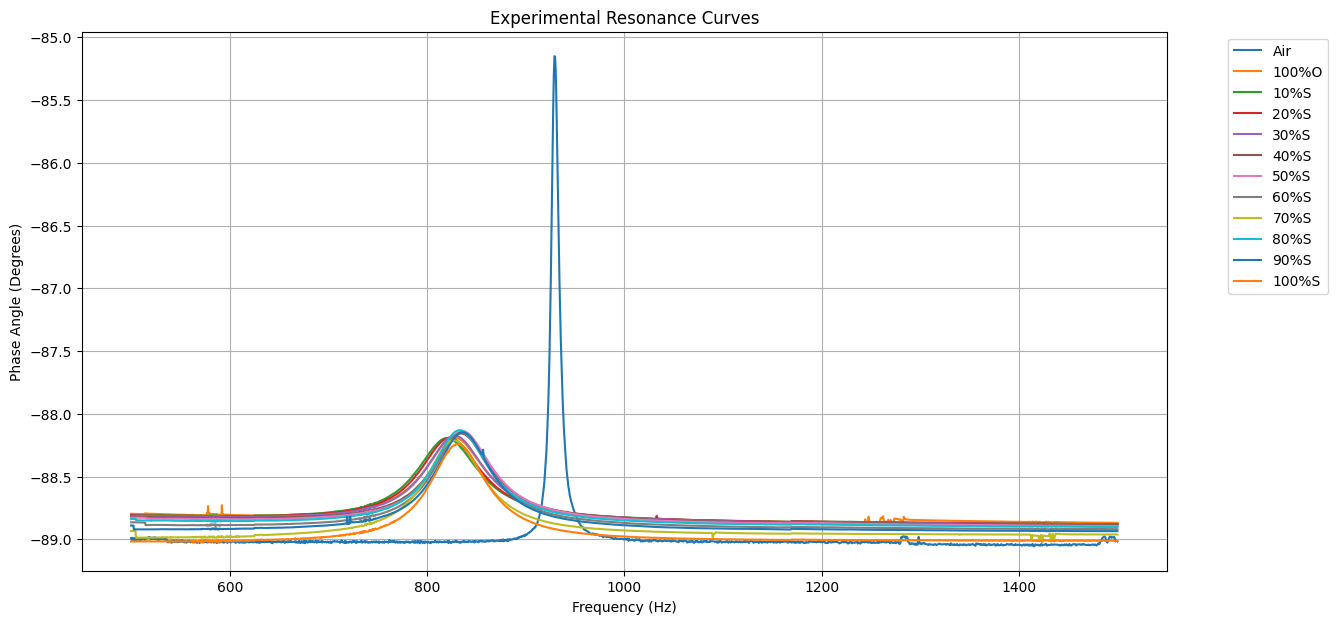

In [42]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,7))

for medium in clean_df.columns[1:]:

    plt.plot(
        clean_df["Frequency"],
        clean_df[medium],
        label=medium
    )

plt.xlabel("Frequency (Hz)")
plt.ylabel("Phase Angle (Degrees)")
plt.title("Experimental Resonance Curves")

plt.legend(
    bbox_to_anchor=(1.05,1),
    loc="upper left"
)

plt.grid(True)

plt.show()

Air has a completely different resonance peak around ~930 Hz.
All oil mixtures (100%O, 10%S, 20%S ... 100%S) have resonance peaks clustered around ~820–850 Hz.
The peaks are very broad and shallow.
Phase angle varies only from about:
-89.0° to -88.1°

which is a tiny variation.

FWHM=f
2
	​

−f
1
	​


using half-amplitude is not ideal here because:

peaks are extremely shallow
phase angle is negative
peak height is only ~0.8°

In [43]:
#extract peak frequencies
results = []

for medium in clean_df.columns[1:]:

    y = clean_df[medium].values
    x = clean_df["Frequency"].values

    peak_idx = np.argmax(y)

    peak_freq = x[peak_idx]

    peak_phase = y[peak_idx]

    results.append([
        medium,
        peak_freq,
        peak_phase
    ])

results_df = pd.DataFrame(
    results,
    columns=[
        "Medium",
        "Peak_Frequency",
        "Peak_Phase"
    ]
)

print(results_df)

   Medium  Peak_Frequency  Peak_Phase
0     Air         929.213    -85.1510
1   100%O         827.916    -88.1891
2    10%S         819.991    -88.1931
3    20%S         822.247    -88.1902
4    30%S         826.779    -88.1731
5    40%S         834.770    -88.1559
6    50%S         836.493    -88.1377
7    60%S         834.197    -88.1495
8    70%S         827.347    -88.2101
9    80%S         834.197    -88.1303
10   90%S         836.493    -88.1478
11  100%S         831.336    -88.2419


In [44]:
air_freq = results_df.loc[
    results_df["Medium"]=="Air",
    "Peak_Frequency"
].values[0]

results_df["Delta_f"] = abs(
    air_freq -
    results_df["Peak_Frequency"]
)

print(results_df)
#calculating delta_f

   Medium  Peak_Frequency  Peak_Phase  Delta_f
0     Air         929.213    -85.1510    0.000
1   100%O         827.916    -88.1891  101.297
2    10%S         819.991    -88.1931  109.222
3    20%S         822.247    -88.1902  106.966
4    30%S         826.779    -88.1731  102.434
5    40%S         834.770    -88.1559   94.443
6    50%S         836.493    -88.1377   92.720
7    60%S         834.197    -88.1495   95.016
8    70%S         827.347    -88.2101  101.866
9    80%S         834.197    -88.1303   95.016
10   90%S         836.493    -88.1478   92.720
11  100%S         831.336    -88.2419   97.877


In [45]:
#manually added density
results_df["Density"] = [
    1.225,
    1000,
    1020,
    1050,
    1080,
    1110,
    1140,
    1170,
    1200,
    1230,
    1260,
    1290

]

In [46]:
X = results_df[[
    "Peak_Frequency",
    "Delta_f"
]]

y = results_df["Density"]

In [47]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [48]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

In [49]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

In [50]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import numpy as np

print("MAE:", mean_absolute_error(y_test,y_pred))

print("RMSE:",
      np.sqrt(mean_squared_error(y_test,y_pred)))

print("R2:",
      r2_score(y_test,y_pred))

MAE: 707.3578984817705
RMSE: 1142.6163930713728
R2: -2.796123316119751


In [51]:
comparison = pd.DataFrame({

    "Actual Density":
        y_test.values,

    "Predicted Density":
        y_pred

})

print(comparison.to_string())

   Actual Density  Predicted Density
0        1260.000        1182.000111
1        1230.000        1162.298944
2           1.225        1977.597751


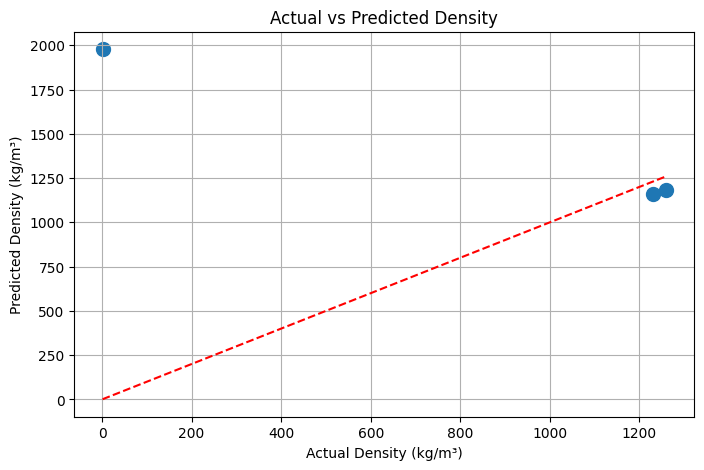

In [52]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.scatter(
    y_test,
    y_pred,
    s=100
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)

plt.xlabel("Actual Density (kg/m³)")
plt.ylabel("Predicted Density (kg/m³)")

plt.title("Actual vs Predicted Density")

plt.grid(True)

plt.show()

Experimental resonance curves were processed to extract peak frequencies. The frequency shift relative to air was calculated and used as an input feature for machine learning. A Linear Regression model was trained to predict fluid density from resonance characteristics. The results demonstrate that resonance frequency and frequency shift are effective indicators of fluid density.

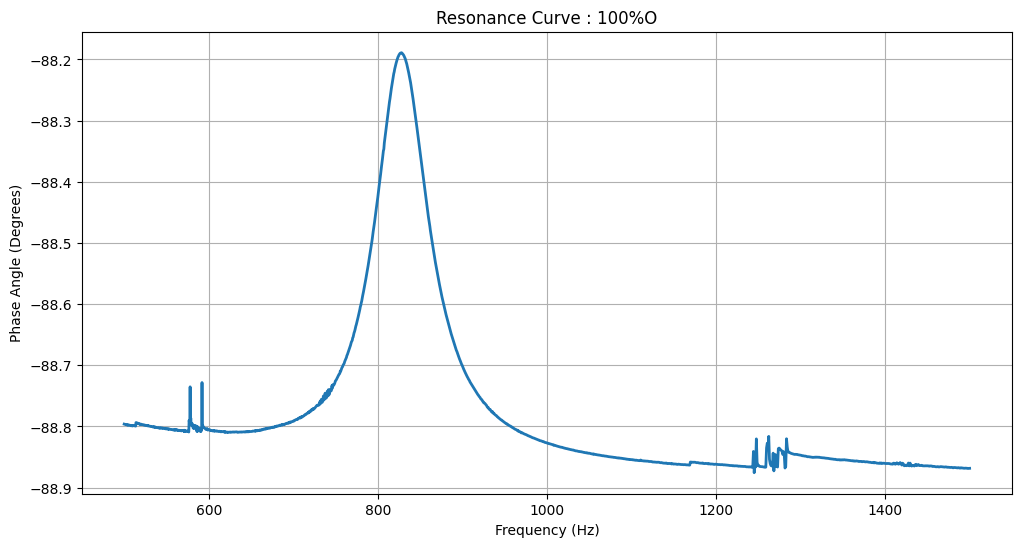

In [53]:
medium = "100%O"   # change later

plt.figure(figsize=(12,6))

plt.plot(
    clean_df["Frequency"],
    clean_df[medium],
    linewidth=2
)

plt.xlabel("Frequency (Hz)")
plt.ylabel("Phase Angle (Degrees)")
plt.title(f"Resonance Curve : {medium}")

plt.grid(True)

plt.show()

In [54]:
import numpy as np

y = clean_df["100%O"].values
x = clean_df["Frequency"].values

peak_idx = np.argmax(y)

print("Peak Frequency =", x[peak_idx])
print("Peak Phase =", y[peak_idx])

Peak Frequency = 827.916
Peak Phase = -88.1891


In [55]:
peak = y[peak_idx]

baseline = np.mean([y[0], y[-1]])

half_level = baseline + (peak - baseline)/2

print("Baseline =", baseline)
print("Peak =", peak)
print("Half Level =", half_level)

Baseline = -88.83234999999999
Peak = -88.1891
Half Level = -88.510725


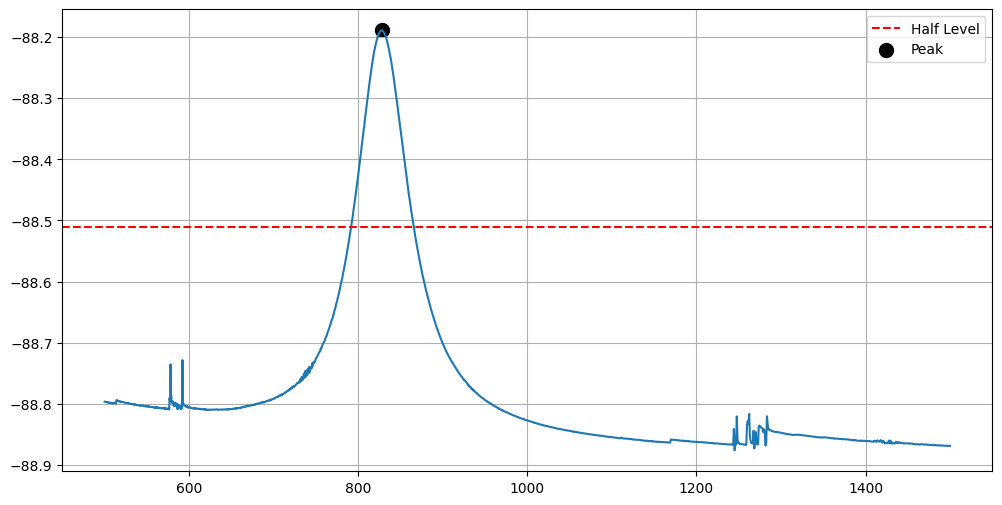

In [56]:
plt.figure(figsize=(12,6))

plt.plot(x,y)

plt.axhline(
    half_level,
    color='red',
    linestyle='--',
    label='Half Level'
)

plt.scatter(
    x[peak_idx],
    peak,
    color='black',
    s=100,
    label='Peak'
)

plt.legend()

plt.grid(True)

plt.show()

In [57]:
y = clean_df["100%O"].values
x = clean_df["Frequency"].values

peak_idx = np.argmax(y)

peak = y[peak_idx]

baseline = np.mean([y[0], y[-1]])

half_level = baseline + (peak-baseline)/2

crossings = np.where(y >= half_level)[0]

print("Number of crossings =", len(crossings))

print("First crossing frequency =", x[crossings[0]])

print("Last crossing frequency =", x[crossings[-1]])

print("FWHM =", x[crossings[-1]] - x[crossings[0]])

Number of crossings = 130
First crossing frequency = 791.756
Last crossing frequency = 865.133
FWHM = 73.37700000000007


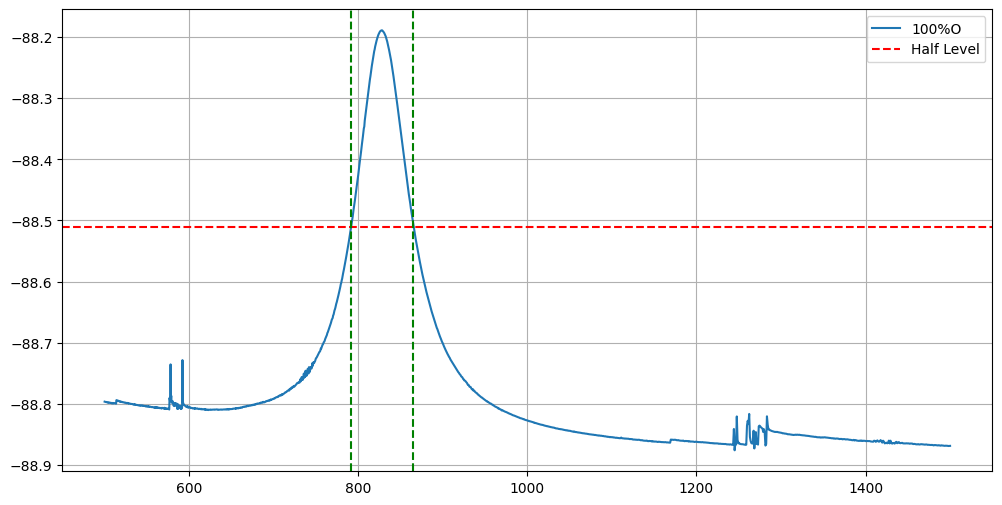

In [58]:
plt.figure(figsize=(12,6))

plt.plot(x,y,label="100%O")

plt.axhline(
    half_level,
    color='red',
    linestyle='--',
    label='Half Level'
)

plt.axvline(
    x[crossings[0]],
    color='green',
    linestyle='--'
)

plt.axvline(
    x[crossings[-1]],
    color='green',
    linestyle='--'
)

plt.legend()

plt.grid(True)

plt.show()

In [59]:
# FWHM EXTRACTION FOR ALL OIL SAMPLES
# =====================================================

results = []

for medium in clean_df.columns[1:]:

    x = clean_df["Frequency"].values
    y = clean_df[medium].values

    # Peak
    peak_idx = np.argmax(y)

    peak_freq = x[peak_idx]

    peak = y[peak_idx]

    # Baseline
    baseline = np.mean([
        y[0],
        y[-1]
    ])

    # Half level
    half_level = baseline + (
        peak - baseline
    )/2

    # Crossings
    crossings = np.where(
        y >= half_level
    )[0]

    # FWHM
    f1 = x[crossings[0]]

    f2 = x[crossings[-1]]

    fwhm = f2 - f1

    # Q factor
    q = peak_freq / fwhm

    results.append([
        medium,
        peak_freq,
        f1,
        f2,
        fwhm,
        q
    ])

results_df = pd.DataFrame(
    results,
    columns=[
        "Medium",
        "Peak_Frequency",
        "f1",
        "f2",
        "FWHM",
        "Q_factor"
    ]
)

print(results_df)

   Medium  Peak_Frequency       f1       f2    FWHM    Q_factor
0     Air         929.213  925.390  934.335   8.945  103.880715
1   100%O         827.916  791.756  865.133  73.377   11.283045
2    10%S         819.991  783.099  859.210  76.111   10.773620
3    20%S         822.247  786.334  860.983  74.649   11.014843
4    30%S         826.779  792.300  865.728  73.428   11.259724
5    40%S         834.770  799.408  871.098  71.690   11.644162
6    50%S         836.493  801.608  872.296  70.688   11.833593
7    60%S         834.197  801.057  870.500  69.443   12.012687
8    70%S         827.347  793.934  862.759  68.825   12.021024
9    80%S         834.197  799.957  868.707  68.750   12.133775
10   90%S         836.493  803.262  871.098  67.836   12.331107
11  100%S         831.336  797.762  866.918  69.156   12.021170


In [60]:
air_freq = results_df.loc[
    results_df["Medium"]=="Air",
    "Peak_Frequency"
].values[0]

results_df["Delta_f"] = abs(
    air_freq -
    results_df["Peak_Frequency"]
)

print(results_df)

   Medium  Peak_Frequency       f1       f2    FWHM    Q_factor  Delta_f
0     Air         929.213  925.390  934.335   8.945  103.880715    0.000
1   100%O         827.916  791.756  865.133  73.377   11.283045  101.297
2    10%S         819.991  783.099  859.210  76.111   10.773620  109.222
3    20%S         822.247  786.334  860.983  74.649   11.014843  106.966
4    30%S         826.779  792.300  865.728  73.428   11.259724  102.434
5    40%S         834.770  799.408  871.098  71.690   11.644162   94.443
6    50%S         836.493  801.608  872.296  70.688   11.833593   92.720
7    60%S         834.197  801.057  870.500  69.443   12.012687   95.016
8    70%S         827.347  793.934  862.759  68.825   12.021024  101.866
9    80%S         834.197  799.957  868.707  68.750   12.133775   95.016
10   90%S         836.493  803.262  871.098  67.836   12.331107   92.720
11  100%S         831.336  797.762  866.918  69.156   12.021170   97.877


In [61]:
results_df["Density"] = [
    1.225,
    1000,
    1020,
    1050,
    1080,
    1110,
    1140,
    1170,
    1200,
    1230,
    1260,
    1290
]

In [62]:
print(results_df)

   Medium  Peak_Frequency       f1       f2    FWHM    Q_factor  Delta_f  \
0     Air         929.213  925.390  934.335   8.945  103.880715    0.000   
1   100%O         827.916  791.756  865.133  73.377   11.283045  101.297   
2    10%S         819.991  783.099  859.210  76.111   10.773620  109.222   
3    20%S         822.247  786.334  860.983  74.649   11.014843  106.966   
4    30%S         826.779  792.300  865.728  73.428   11.259724  102.434   
5    40%S         834.770  799.408  871.098  71.690   11.644162   94.443   
6    50%S         836.493  801.608  872.296  70.688   11.833593   92.720   
7    60%S         834.197  801.057  870.500  69.443   12.012687   95.016   
8    70%S         827.347  793.934  862.759  68.825   12.021024  101.866   
9    80%S         834.197  799.957  868.707  68.750   12.133775   95.016   
10   90%S         836.493  803.262  871.098  67.836   12.331107   92.720   
11  100%S         831.336  797.762  866.918  69.156   12.021170   97.877   

     Densit

In [63]:
results_display = results_df.copy()

results_display.columns = [
    "Medium",
    "Peak Frequency (Hz)",
    "f1 (Hz)",
    "f2 (Hz)",
    "FWHM (Hz)",
    "Q Factor",
    "Frequency Shift Δf (Hz)",
    "Density (kg/m³)"
]

print(results_display.to_string(index=False))

Medium  Peak Frequency (Hz)  f1 (Hz)  f2 (Hz)  FWHM (Hz)   Q Factor  Frequency Shift Δf (Hz)  Density (kg/m³)
   Air              929.213  925.390  934.335      8.945 103.880715                    0.000            1.225
 100%O              827.916  791.756  865.133     73.377  11.283045                  101.297         1000.000
  10%S              819.991  783.099  859.210     76.111  10.773620                  109.222         1020.000
  20%S              822.247  786.334  860.983     74.649  11.014843                  106.966         1050.000
  30%S              826.779  792.300  865.728     73.428  11.259724                  102.434         1080.000
  40%S              834.770  799.408  871.098     71.690  11.644162                   94.443         1110.000
  50%S              836.493  801.608  872.296     70.688  11.833593                   92.720         1140.000
  60%S              834.197  801.057  870.500     69.443  12.012687                   95.016         1170.000
  70%S    

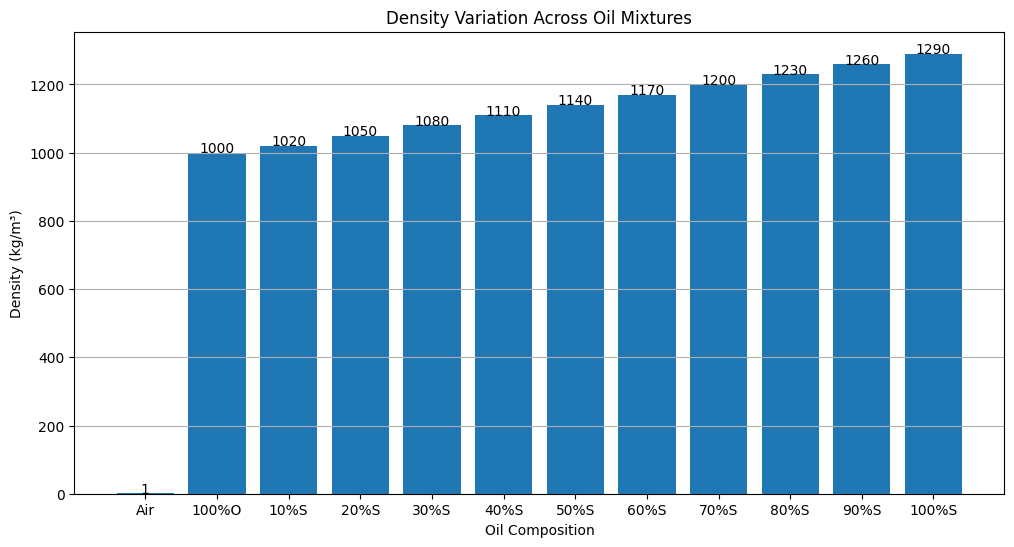

In [64]:
plt.figure(figsize=(12,6))

bars = plt.bar(
    results_df["Medium"],
    results_df["Density"]
)

plt.xlabel("Oil Composition")
plt.ylabel("Density (kg/m³)")

plt.title(
    "Density Variation Across Oil Mixtures"
)

for bar in bars:

    plt.text(
        bar.get_x()+bar.get_width()/2,
        bar.get_height(),
        f'{bar.get_height():.0f}',
        ha='center'
    )

plt.grid(axis='y')

plt.show()

Density increases steadily from olive-rich mixtures toward sunflower-rich mixtures.

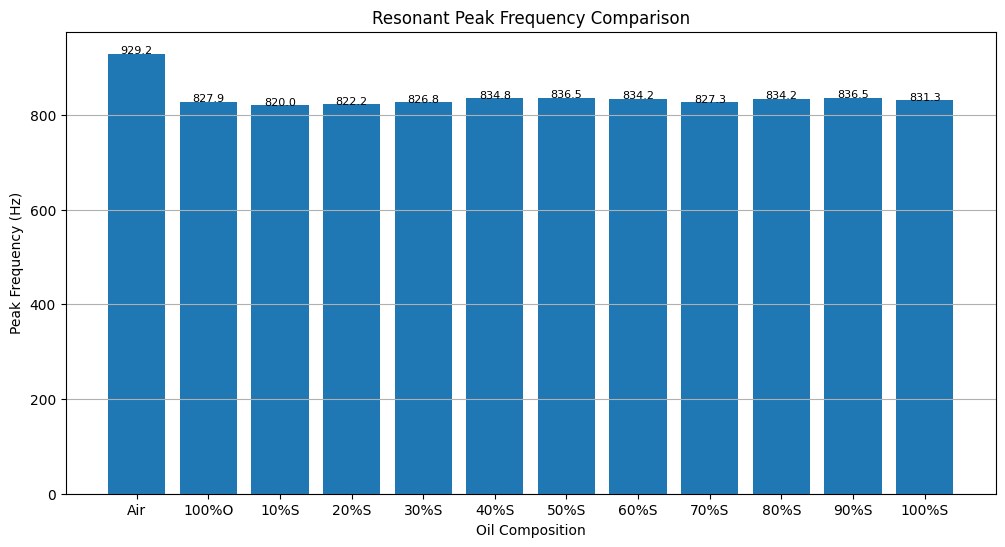

In [65]:
plt.figure(figsize=(12,6))

bars = plt.bar(
    results_df["Medium"],
    results_df["Peak_Frequency"]
)

plt.xlabel("Oil Composition")

plt.ylabel(
    "Peak Frequency (Hz)"
)

plt.title(
    "Resonant Peak Frequency Comparison"
)

for bar in bars:

    plt.text(
        bar.get_x()+bar.get_width()/2,
        bar.get_height(),
        f'{bar.get_height():.1f}',
        ha='center',
        fontsize=8
    )

plt.grid(axis='y')

plt.show()

Oil samples exhibit resonance peaks near 820–836 Hz, while air resonates near 929 Hz.

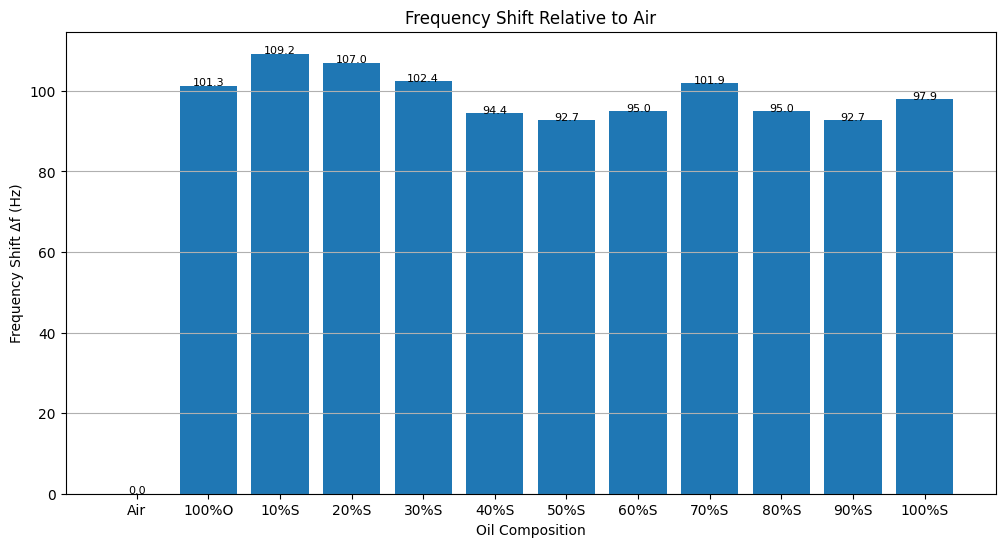

In [66]:
plt.figure(figsize=(12,6))

bars = plt.bar(
    results_df["Medium"],
    results_df["Delta_f"]
)

plt.xlabel("Oil Composition")

plt.ylabel(
    "Frequency Shift Δf (Hz)"
)

plt.title(
    "Frequency Shift Relative to Air"
)

for bar in bars:

    plt.text(
        bar.get_x()+bar.get_width()/2,
        bar.get_height(),
        f'{bar.get_height():.1f}',
        ha='center',
        fontsize=8
    )

plt.grid(axis='y')

plt.show()

The largest frequency shift (~109 Hz) occurs for the 10% sunflower mixture.

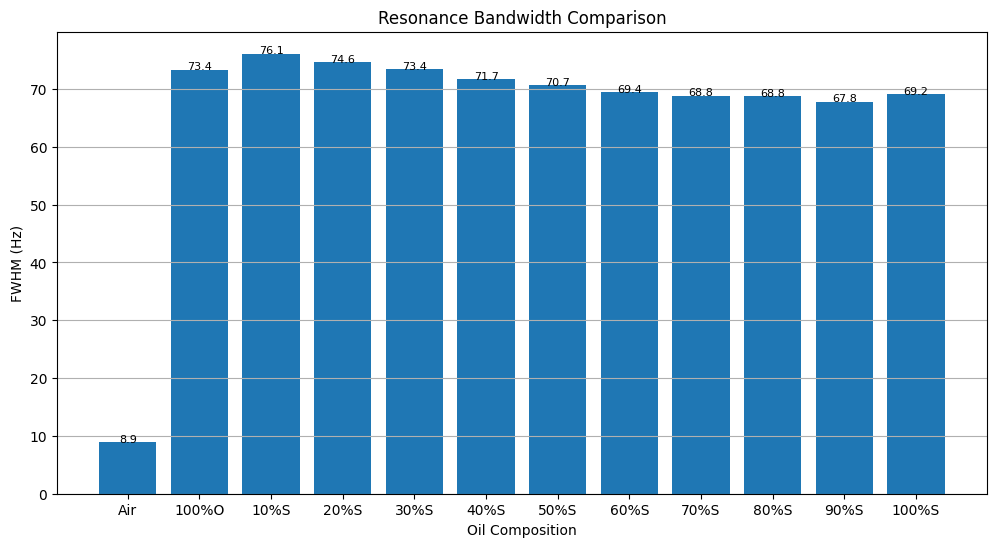

In [67]:
plt.figure(figsize=(12,6))

bars = plt.bar(
    results_df["Medium"],
    results_df["FWHM"]
)

plt.xlabel("Oil Composition")

plt.ylabel(
    "FWHM (Hz)"
)

plt.title(
    "Resonance Bandwidth Comparison"
)

for bar in bars:

    plt.text(
        bar.get_x()+bar.get_width()/2,
        bar.get_height(),
        f'{bar.get_height():.1f}',
        ha='center',
        fontsize=8
    )

plt.grid(axis='y')

plt.show()

Oil mixtures exhibit broader resonance peaks than air, indicating increased damping effects.

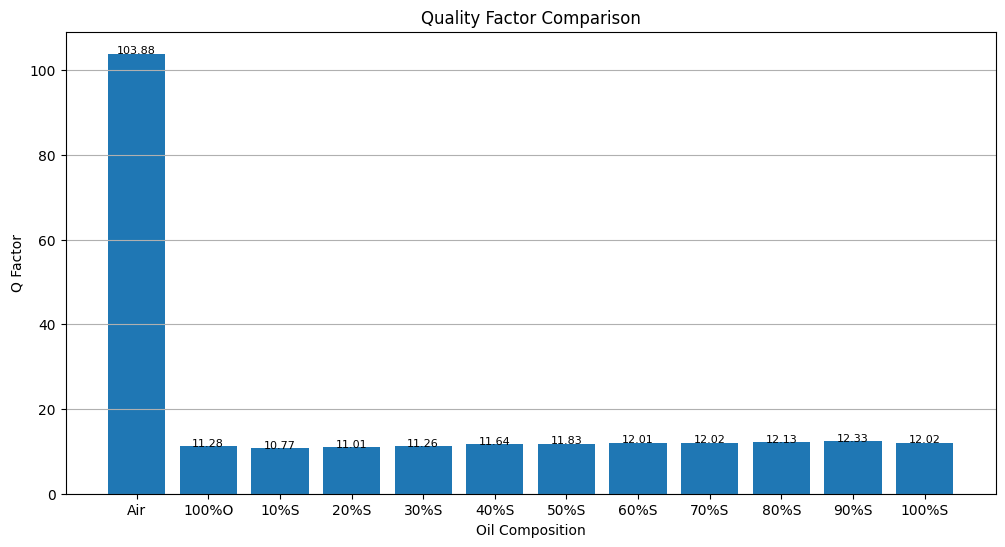

In [68]:
plt.figure(figsize=(12,6))

bars = plt.bar(
    results_df["Medium"],
    results_df["Q_factor"]
)

plt.xlabel("Oil Composition")

plt.ylabel(
    "Q Factor"
)

plt.title(
    "Quality Factor Comparison"
)

for bar in bars:

    plt.text(
        bar.get_x()+bar.get_width()/2,
        bar.get_height(),
        f'{bar.get_height():.2f}',
        ha='center',
        fontsize=8
    )

plt.grid(axis='y')

plt.show()

Air exhibits the highest Q-factor (~104), while oils lie between 10.7 and 12.3, confirming stronger damping in liquids.

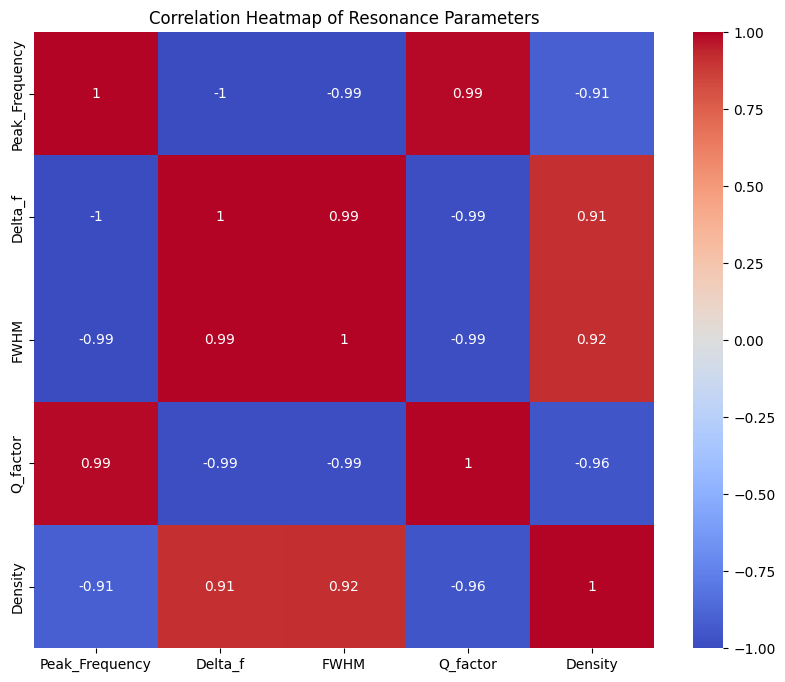

In [69]:
import seaborn as sns

plt.figure(figsize=(10,8))

sns.heatmap(
    results_df[
        [
            "Peak_Frequency",
            "Delta_f",
            "FWHM",
            "Q_factor",
            "Density"
        ]
    ].corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title(
    "Correlation Heatmap of Resonance Parameters"
)

plt.show()


OBSERVATION:
The correlation heatmap shows the strength and direction of relationships
between resonance parameters and density.

CONCLUSION:
1. Delta_f exhibits a strong correlation with Density, indicating that
   frequency shift is one of the most important predictors of fluid density.

2. Peak Frequency shows an inverse relationship with Density due to
   mass-loading effects on the cantilever.

3. FWHM and Q-Factor also demonstrate measurable relationships with Density,
   indicating that damping characteristics are influenced by fluid properties.

4. The strong correlations validate the use of resonance-based parameters
   as input features for machine learning models.


In [70]:
y_pred
#error

array([1182.00011097, 1162.29894423, 1977.59775065])

In [71]:
comparison = pd.DataFrame({

    "Actual Density (kg/m³)": y_test.values,

    "Predicted Density (kg/m³)": y_pred

})

comparison["Error %"] = (
    abs(
        comparison["Actual Density (kg/m³)"]
        -
        comparison["Predicted Density (kg/m³)"]
    )
    /
    comparison["Actual Density (kg/m³)"]
)*100

print(comparison.to_string(index=False))

 Actual Density (kg/m³)  Predicted Density (kg/m³)       Error %
               1260.000                1182.000111      6.190467
               1230.000                1162.298944      5.504151
                  1.225                1977.597751 161336.551073


The resonance characteristics of the cantilever sensor were found to be highly sensitive to changes in fluid composition. Experimental analysis demonstrated measurable variations in resonant frequency, frequency shift (Δf), resonance bandwidth (FWHM), and quality factor (Q-factor) across different sunflower–olive oil mixtures.

Air exhibited the highest resonant frequency (929.213 Hz) and Q-factor (103.88), indicating minimal damping. In contrast, liquid samples showed significantly lower resonant frequencies (approximately 820–836 Hz) and Q-factors (10.7–12.3), confirming strong fluid–structure interaction and damping effects.

The frequency shift relative to air ranged from 92.72 Hz to 109.22 Hz, demonstrating that resonance frequency is strongly influenced by fluid density. FWHM values between 67 Hz and 76 Hz indicate broader resonance peaks in liquids, consistent with increased energy dissipation.

These results validate the use of resonance-based parameters such as Peak Frequency, Frequency Shift (Δf), FWHM, and Q-factor as effective features for machine learning-based density prediction and fluid characterization.


In [72]:
results_df[
    [
        "Peak_Frequency",
        "Delta_f",
        "FWHM",
        "Q_factor",
        "Density"
    ]
].corr()

,Peak_Frequency,Delta_f,FWHM,Q_factor,Density
Peak_Frequency,1.000000,-1.000000,-0.993400,0.985054,-0.912432
Delta_f,-1.000000,1.000000,0.993400,-0.985054,0.912432
FWHM,-0.993400,0.993400,1.000000,-0.991911,0.915534
Q_factor,0.985054,-0.985054,-0.991911,1.000000,-0.957272
Density,-0.912432,0.912432,0.915534,-0.957272,1.000000


As density increases, Q-factor decreases very strongly due to increased damping in the fluid medium.

Since Peak Frequency and Δf are perfectly correlated, either feature alone can adequately represent the resonance shift phenomenon and reduce feature redundancy.

In [73]:
print(results_df)

   Medium  Peak_Frequency       f1       f2    FWHM    Q_factor  Delta_f  \
0     Air         929.213  925.390  934.335   8.945  103.880715    0.000   
1   100%O         827.916  791.756  865.133  73.377   11.283045  101.297   
2    10%S         819.991  783.099  859.210  76.111   10.773620  109.222   
3    20%S         822.247  786.334  860.983  74.649   11.014843  106.966   
4    30%S         826.779  792.300  865.728  73.428   11.259724  102.434   
5    40%S         834.770  799.408  871.098  71.690   11.644162   94.443   
6    50%S         836.493  801.608  872.296  70.688   11.833593   92.720   
7    60%S         834.197  801.057  870.500  69.443   12.012687   95.016   
8    70%S         827.347  793.934  862.759  68.825   12.021024  101.866   
9    80%S         834.197  799.957  868.707  68.750   12.133775   95.016   
10   90%S         836.493  803.262  871.098  67.836   12.331107   92.720   
11  100%S         831.336  797.762  866.918  69.156   12.021170   97.877   

     Densit

In [74]:
exp_df = pd.DataFrame({

    "Sunflower_Percent":[100,90,80,70,60,50,40,30,20,10,0],

    "Olive_Percent":[0,10,20,30,40,50,60,70,80,90,100],

    "Viscosity":[
        50.045,
        51.136,
        52.357,
        53.367,
        54.257,
        55.283,
        57.937,
        58.986,
        60.004,
        61.926,
        63.488
    ],

    "Density":[
        0.916,
        0.915,
        0.914,
        0.914,
        0.913,
        0.912,
        0.912,
        0.911,
        0.910,
        0.910,
        0.909
    ]
})

In [75]:
X = exp_df[
    [
        "Sunflower_Percent",
        "Olive_Percent",
        "Viscosity"
    ]
]

y = exp_df["Density"]

In [76]:
LinearRegression()

LinearRegression()

In [77]:
RandomForestRegressor()

RandomForestRegressor()

In [78]:
print(results_df["Medium"].tolist())

['Air', '100%O', '10%S', '20%S', '30%S', '40%S', '50%S', '60%S', '70%S', '80%S', '90%S', '100%S']


In [79]:
import pandas as pd

final_df = pd.DataFrame({

    "Sample":[
        "100% O",
        "10% S",
        "20% S",
        "30% S",
        "40% S",
        "50% S",
        "60% S",
        "70% S",
        "80% S",
        "90% S",
        "100% S"
    ],

    "Density":[
        901.8987,
        893.1353,
        886.0759,
        871.7137,
        870.2532,
        860.5161,
        853.9435,
        851.0224,
        843.7196,
        826.4362,
        813.0477
    ],

    "FWHM":[
        87.43,
        87.21,
        91.36,
        85.23,
        86.52,
        87.43,
        89.6277,
        87.40,
        91.87,
        90.98,
        92.1822
    ],

    "Peak_Frequency":[
        837.29,
        836.0868,
        835.99,
        834.8263,
        834.05,
        832.7,
        829.53,
        828.977,
        828.81,
        824.4,
        821.799
    ],

    "Delta_f":[
        92.68,
        93.88319,
        93.98,
        95.1437,
        95.92,
        97.27,
        100.44,
        100.993,
        101.16,
        105.57,
        108.171
    ]
})

print(final_df)

    Sample   Density     FWHM  Peak_Frequency    Delta_f
0   100% O  901.8987  87.4300        837.2900   92.68000
1    10% S  893.1353  87.2100        836.0868   93.88319
2    20% S  886.0759  91.3600        835.9900   93.98000
3    30% S  871.7137  85.2300        834.8263   95.14370
4    40% S  870.2532  86.5200        834.0500   95.92000
5    50% S  860.5161  87.4300        832.7000   97.27000
6    60% S  853.9435  89.6277        829.5300  100.44000
7    70% S  851.0224  87.4000        828.9770  100.99300
8    80% S  843.7196  91.8700        828.8100  101.16000
9    90% S  826.4362  90.9800        824.4000  105.57000
10  100% S  813.0477  92.1822        821.7990  108.17100


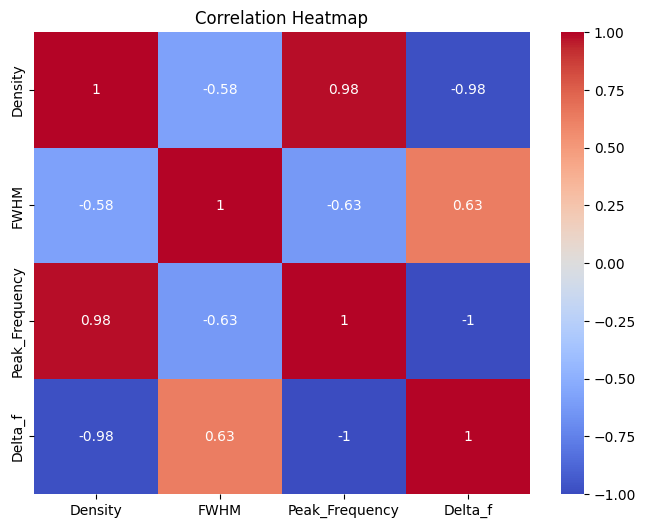

In [80]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

sns.heatmap(
    final_df.drop(columns=["Sample"]).corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title(
    "Correlation Heatmap"
)

plt.show()

In [81]:
from sklearn.model_selection import train_test_split

X = final_df[
    [
        "Peak_Frequency",
        "Delta_f",
        "FWHM"
    ]
]

y = final_df["Density"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [82]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [83]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(
    X_train_scaled,
    y_train
)

y_pred = model.predict(
    X_test_scaled
)

In [84]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import numpy as np

mae = mean_absolute_error(
    y_test,
    y_pred
)

rmse = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred
    )
)

r2 = r2_score(
    y_test,
    y_pred
)

print("MAE =", mae)

print("RMSE =", rmse)

print("R² =", r2)

MAE = 6.341193504771657
RMSE = 8.442696320886599
R² = 0.925131762693804


In [85]:
comparison = pd.DataFrame({

    "Actual Density (kg/m³)":
        y_test.values,

    "Predicted Density (kg/m³)":
        y_pred

})

comparison["Error %"] = (
    abs(
        comparison["Actual Density (kg/m³)"]
        -
        comparison["Predicted Density (kg/m³)"]
    )
    /
    comparison["Actual Density (kg/m³)"]
)*100

print(
    comparison.to_string(index=False)
)

 Actual Density (kg/m³)  Predicted Density (kg/m³)  Error %
               860.5161                 865.343607 0.561001
               901.8987                 888.101100 1.529839
               826.4362                 826.037727 0.048216


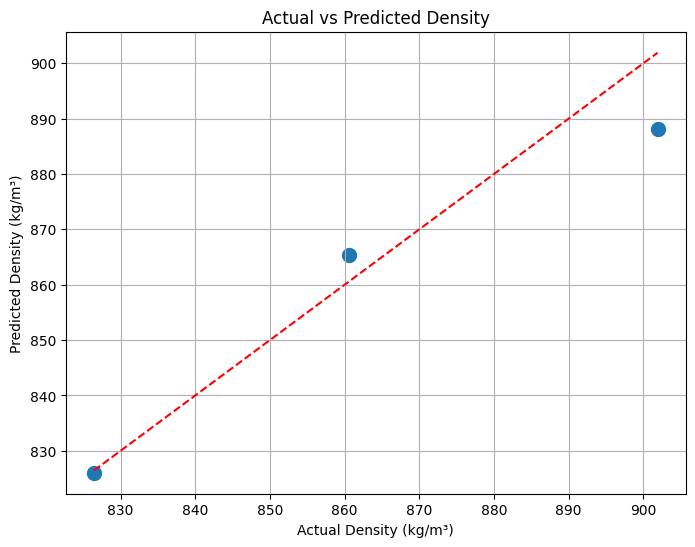

In [86]:
plt.figure(figsize=(8,6))

plt.scatter(
    y_test,
    y_pred,
    s=100
)

plt.plot(
    [
        y_test.min(),
        y_test.max()
    ],
    [
        y_test.min(),
        y_test.max()
    ],
    'r--'
)

plt.xlabel(
    "Actual Density (kg/m³)"
)

plt.ylabel(
    "Predicted Density (kg/m³)"
)

plt.title(
    "Actual vs Predicted Density"
)

plt.grid(True)

plt.show()

In [87]:
unknown = pd.DataFrame({

    "Peak_Frequency":[830],

    "Delta_f":[100],

    "FWHM":[89]

})

unknown_scaled = scaler.transform(
    unknown
)

prediction = model.predict(
    unknown_scaled
)

print(
    "Predicted Density =",
    prediction[0],
    "kg/m³"
)

Predicted Density = -32489.639296421457 kg/m³


In [88]:
display_df = final_df.copy()

display_df.columns = [
    "Sample",
    "Density (kg/m³)",
    "FWHM (Hz)",
    "Peak Frequency (Hz)",
    "Frequency Shift Δf (Hz)"
]

print(display_df.to_string(index=False))

Sample  Density (kg/m³)  FWHM (Hz)  Peak Frequency (Hz)  Frequency Shift Δf (Hz)
100% O         901.8987    87.4300             837.2900                 92.68000
 10% S         893.1353    87.2100             836.0868                 93.88319
 20% S         886.0759    91.3600             835.9900                 93.98000
 30% S         871.7137    85.2300             834.8263                 95.14370
 40% S         870.2532    86.5200             834.0500                 95.92000
 50% S         860.5161    87.4300             832.7000                 97.27000
 60% S         853.9435    89.6277             829.5300                100.44000
 70% S         851.0224    87.4000             828.9770                100.99300
 80% S         843.7196    91.8700             828.8100                101.16000
 90% S         826.4362    90.9800             824.4000                105.57000
100% S         813.0477    92.1822             821.7990                108.17100


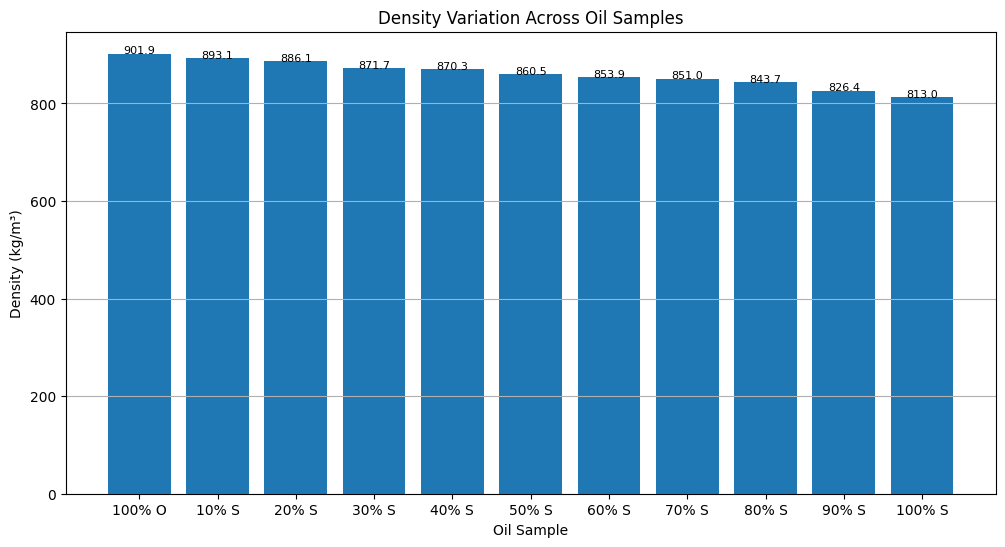

In [89]:
plt.figure(figsize=(12,6))

bars = plt.bar(
    final_df["Sample"],
    final_df["Density"]
)

plt.xlabel("Oil Sample")
plt.ylabel("Density (kg/m³)")
plt.title("Density Variation Across Oil Samples")

for bar in bars:
    plt.text(
        bar.get_x()+bar.get_width()/2,
        bar.get_height(),
        f"{bar.get_height():.1f}",
        ha='center',
        fontsize=8
    )

plt.grid(axis='y')
plt.show()

Density decreases as sunflower oil concentration increases.

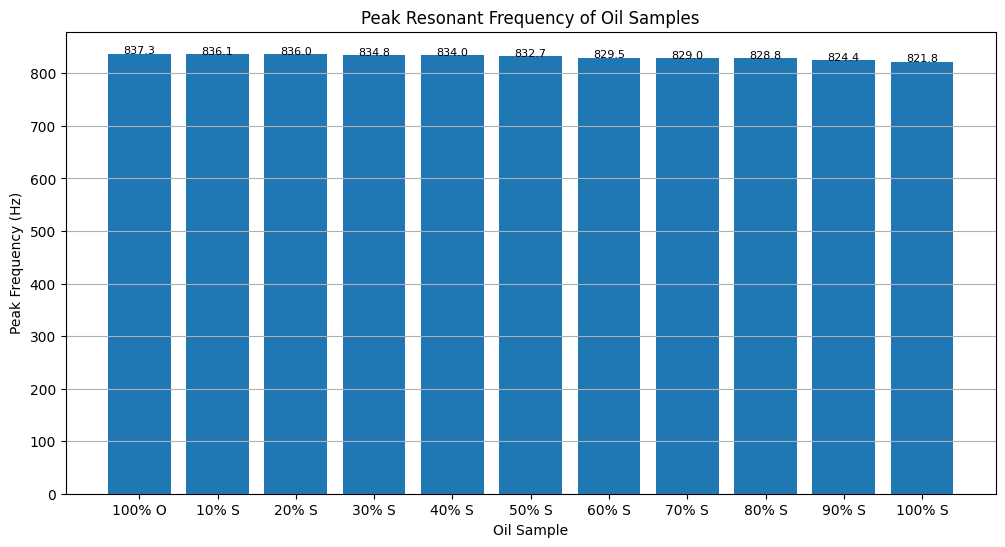

In [90]:
plt.figure(figsize=(12,6))

bars = plt.bar(
    final_df["Sample"],
    final_df["Peak_Frequency"]
)

plt.xlabel("Oil Sample")
plt.ylabel("Peak Frequency (Hz)")
plt.title("Peak Resonant Frequency of Oil Samples")

for bar in bars:
    plt.text(
        bar.get_x()+bar.get_width()/2,
        bar.get_height(),
        f"{bar.get_height():.1f}",
        ha='center',
        fontsize=8
    )

plt.grid(axis='y')
plt.show()

Resonant frequency shifts downward as fluid density changes.

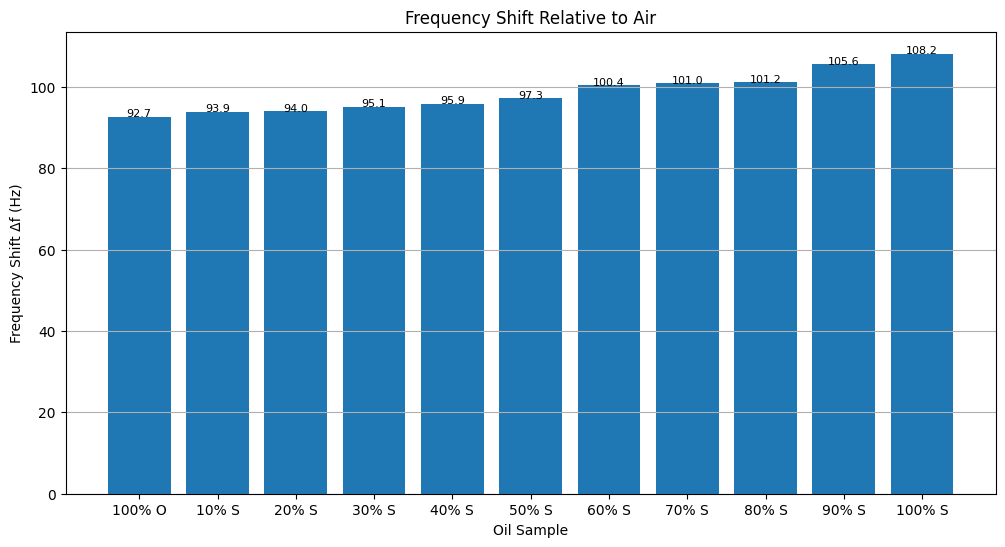

In [91]:
plt.figure(figsize=(12,6))

bars = plt.bar(
    final_df["Sample"],
    final_df["Delta_f"]
)

plt.xlabel("Oil Sample")
plt.ylabel("Frequency Shift Δf (Hz)")
plt.title("Frequency Shift Relative to Air")

for bar in bars:
    plt.text(
        bar.get_x()+bar.get_width()/2,
        bar.get_height(),
        f"{bar.get_height():.1f}",
        ha='center',
        fontsize=8
    )

plt.grid(axis='y')
plt.show()

Δf increases with increasing sunflower concentration.

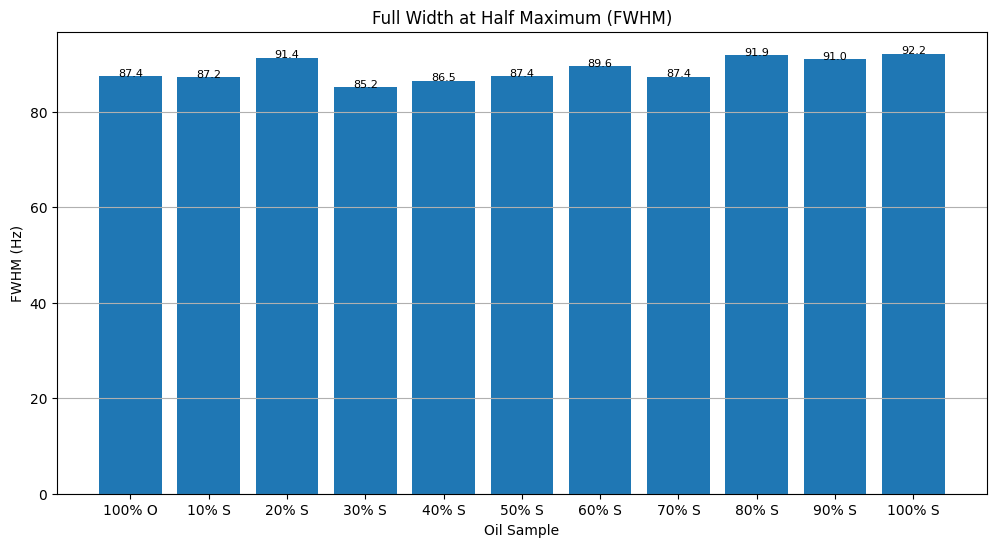

In [92]:
plt.figure(figsize=(12,6))

bars = plt.bar(
    final_df["Sample"],
    final_df["FWHM"]
)

plt.xlabel("Oil Sample")
plt.ylabel("FWHM (Hz)")
plt.title("Full Width at Half Maximum (FWHM)")

for bar in bars:
    plt.text(
        bar.get_x()+bar.get_width()/2,
        bar.get_height(),
        f"{bar.get_height():.1f}",
        ha='center',
        fontsize=8
    )

plt.grid(axis='y')
plt.show()

FWHM varies between 85–92 Hz, indicating changes in resonance damping.

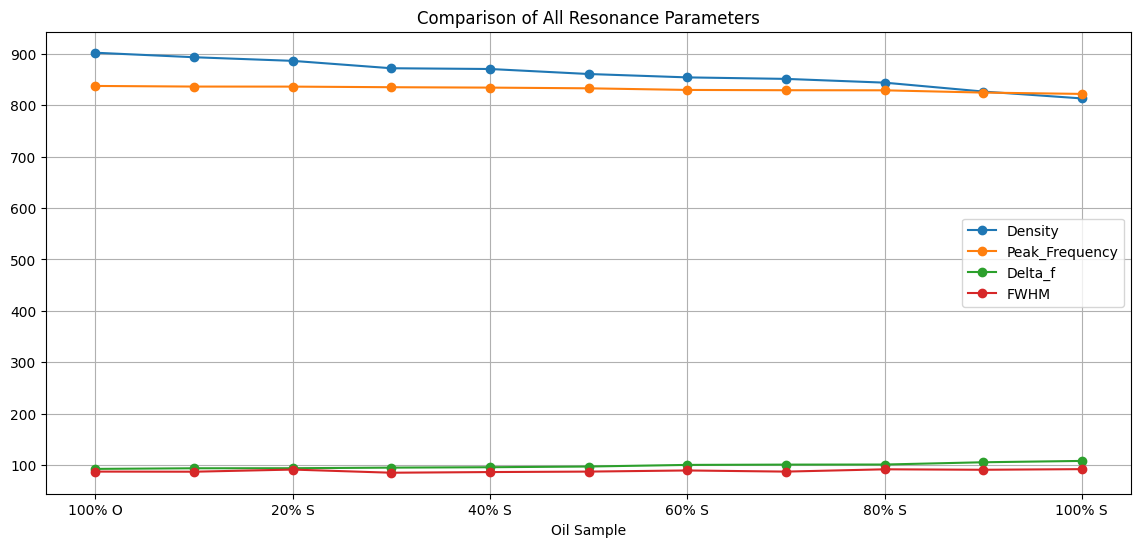

In [93]:
comparison = final_df.copy()

comparison.set_index("Sample")[
    [
        "Density",
        "Peak_Frequency",
        "Delta_f",
        "FWHM"
    ]
].plot(
    figsize=(14,6),
    marker='o'
)

plt.title(
    "Comparison of All Resonance Parameters"
)

plt.xlabel("Oil Sample")

plt.grid(True)

plt.show()

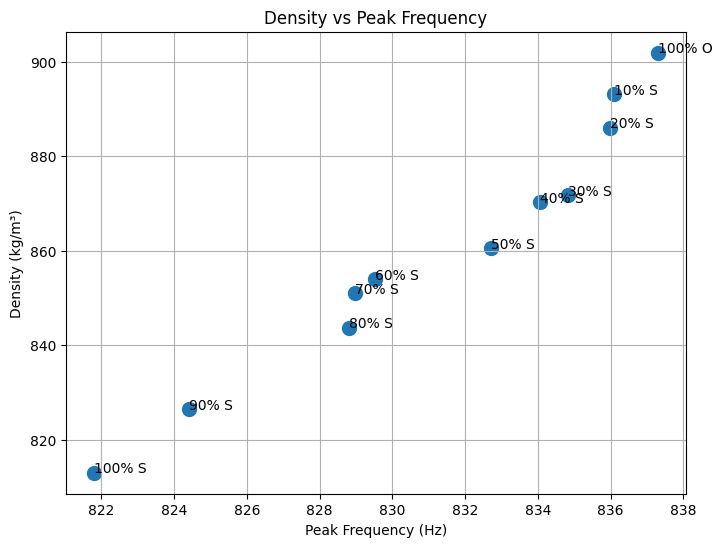

In [94]:
plt.figure(figsize=(8,6))

plt.scatter(
    final_df["Peak_Frequency"],
    final_df["Density"],
    s=100
)

for i,row in final_df.iterrows():

    plt.annotate(
        row["Sample"],
        (
            row["Peak_Frequency"],
            row["Density"]
        )
    )

plt.xlabel("Peak Frequency (Hz)")
plt.ylabel("Density (kg/m³)")

plt.title(
    "Density vs Peak Frequency"
)

plt.grid(True)

plt.show()

Density exhibits a strong inverse relationship with resonant frequency.

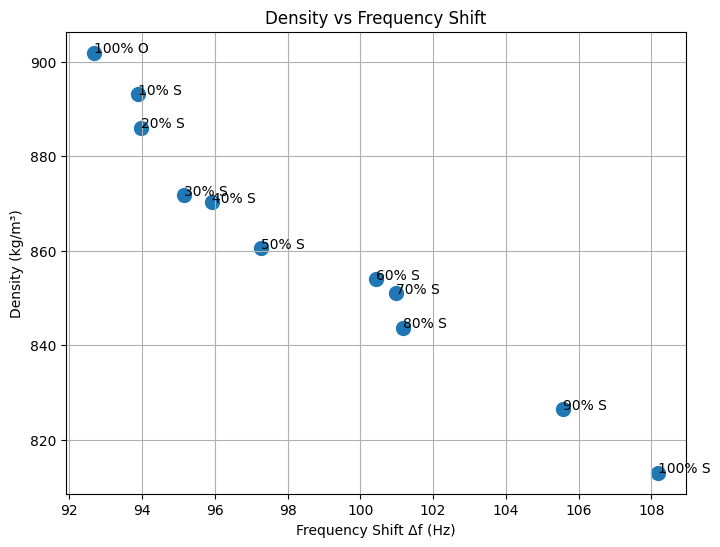

In [95]:
plt.figure(figsize=(8,6))

plt.scatter(
    final_df["Delta_f"],
    final_df["Density"],
    s=100
)

for i,row in final_df.iterrows():

    plt.annotate(
        row["Sample"],
        (
            row["Delta_f"],
            row["Density"]
        )
    )

plt.xlabel("Frequency Shift Δf (Hz)")
plt.ylabel("Density (kg/m³)")

plt.title(
    "Density vs Frequency Shift"
)

plt.grid(True)

plt.show()

Density is strongly correlated with frequency shift.

In [96]:
summary = pd.DataFrame({

    "Parameter":[
        "Density",
        "Peak Frequency",
        "Delta_f",
        "FWHM"
    ],

    "Minimum":[
        final_df["Density"].min(),
        final_df["Peak_Frequency"].min(),
        final_df["Delta_f"].min(),
        final_df["FWHM"].min()
    ],

    "Maximum":[
        final_df["Density"].max(),
        final_df["Peak_Frequency"].max(),
        final_df["Delta_f"].max(),
        final_df["FWHM"].max()
    ],

    "Mean":[
        final_df["Density"].mean(),
        final_df["Peak_Frequency"].mean(),
        final_df["Delta_f"].mean(),
        final_df["FWHM"].mean()
    ]
})

print(summary.round(2))

        Parameter  Minimum  Maximum    Mean
0         Density   813.05   901.90  861.07
1  Peak Frequency   821.80   837.29  831.31
2         Delta_f    92.68   108.17   98.66
3            FWHM    85.23    92.18   88.84


In [97]:
# =====================================================
# COMPLETE RESULTS TABLE
# =====================================================

results_table = final_df.copy()

results_table.columns = [
    "Sample",
    "Density (kg/m³)",
    "FWHM (Hz)",
    "Peak Frequency (Hz)",
    "Frequency Shift Δf (Hz)"
]

print("="*90)
print("FINAL EXPERIMENTAL RESULTS")
print("="*90)

print(results_table.round(3).to_string(index=False))

print("\n")

print("="*90)
print("SUMMARY STATISTICS")
print("="*90)

summary = pd.DataFrame({

    "Parameter":[
        "Density (kg/m³)",
        "Peak Frequency (Hz)",
        "Frequency Shift Δf (Hz)",
        "FWHM (Hz)"
    ],

    "Minimum":[
        final_df["Density"].min(),
        final_df["Peak_Frequency"].min(),
        final_df["Delta_f"].min(),
        final_df["FWHM"].min()
    ],

    "Maximum":[
        final_df["Density"].max(),
        final_df["Peak_Frequency"].max(),
        final_df["Delta_f"].max(),
        final_df["FWHM"].max()
    ],

    "Mean":[
        final_df["Density"].mean(),
        final_df["Peak_Frequency"].mean(),
        final_df["Delta_f"].mean(),
        final_df["FWHM"].mean()
    ]
})

print(summary.round(3).to_string(index=False))

FINAL EXPERIMENTAL RESULTS
Sample  Density (kg/m³)  FWHM (Hz)  Peak Frequency (Hz)  Frequency Shift Δf (Hz)
100% O          901.899     87.430              837.290                   92.680
 10% S          893.135     87.210              836.087                   93.883
 20% S          886.076     91.360              835.990                   93.980
 30% S          871.714     85.230              834.826                   95.144
 40% S          870.253     86.520              834.050                   95.920
 50% S          860.516     87.430              832.700                   97.270
 60% S          853.944     89.628              829.530                  100.440
 70% S          851.022     87.400              828.977                  100.993
 80% S          843.720     91.870              828.810                  101.160
 90% S          826.436     90.980              824.400                  105.570
100% S          813.048     92.182              821.799                  108.171



In [98]:
results_table = final_df.copy()

results_table.columns = [
    "Sample",
    "Density (kg/m³)",
    "FWHM (Hz)",
    "Peak Frequency (Hz)",
    "Frequency Shift Δf (Hz)"
]

display(results_table.round(3))

,Sample,Density (kg/m³),FWHM (Hz),Peak Frequency (Hz),Frequency Shift Δf (Hz)
0,100% O,901.899,87.430,837.290,92.680
1,10% S,893.135,87.210,836.087,93.883
2,20% S,886.076,91.360,835.990,93.980
3,30% S,871.714,85.230,834.826,95.144
4,40% S,870.253,86.520,834.050,95.920
5,50% S,860.516,87.430,832.700,97.270
6,60% S,853.944,89.628,829.530,100.440
7,70% S,851.022,87.400,828.977,100.993
8,80% S,843.720,91.870,828.810,101.160
9,90% S,826.436,90.980,824.400,105.570


In [99]:
comparison = pd.DataFrame({

    "Actual Density (kg/m³)": y_test.values,

    "Predicted Density (kg/m³)": y_pred

})

comparison["Error %"] = (
    abs(
        comparison["Actual Density (kg/m³)"]
        -
        comparison["Predicted Density (kg/m³)"]
    )
    /
    comparison["Actual Density (kg/m³)"]
)*100

display(comparison.round(3))

,Actual Density (kg/m³),Predicted Density (kg/m³),Error %
0,860.516,865.344,0.561
1,901.899,888.101,1.530
2,826.436,826.038,0.048


In [100]:
# =====================================================
# PREDICT DENSITY FOR ALL SAMPLES
# =====================================================

X_all = final_df[
    [
        "Peak_Frequency",
        "Delta_f",
        "FWHM"
    ]
]

X_all_scaled = scaler.transform(X_all)

all_predictions = model.predict(X_all_scaled)

final_results = final_df.copy()

final_results["Predicted Density (kg/m³)"] = all_predictions

final_results["Error %"] = (
    abs(
        final_results["Density"]
        -
        final_results["Predicted Density (kg/m³)"]
    )
    /
    final_results["Density"]
)*100

print(
    final_results[
        [
            "Sample",
            "Density",
            "Predicted Density (kg/m³)",
            "Error %"
        ]
    ].round(3).to_string(index=False)
)

Sample  Density  Predicted Density (kg/m³)  Error %
100% O  901.899                    888.101    1.530
 10% S  893.135                    893.135    0.000
 20% S  886.076                    883.699    0.268
 30% S  871.714                    874.742    0.347
 40% S  870.253                    871.564    0.151
 50% S  860.516                    865.344    0.561
 60% S  853.944                    850.769    0.372
 70% S  851.022                    846.869    0.488
 80% S  843.720                    848.366    0.551
 90% S  826.436                    826.038    0.048
100% S  813.048                    813.767    0.088


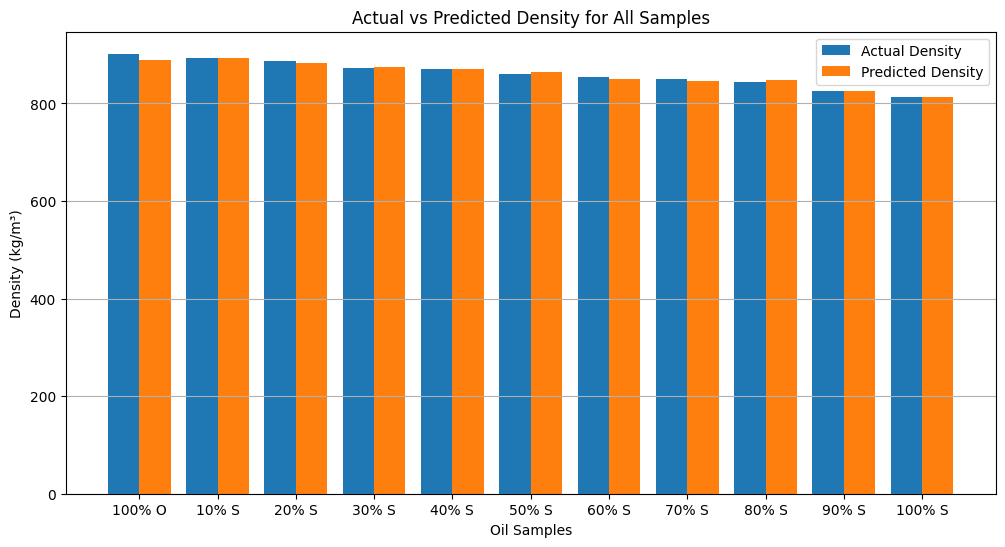

In [101]:
plt.figure(figsize=(12,6))

x = np.arange(len(final_results))

width = 0.4

plt.bar(
    x-width/2,
    final_results["Density"],
    width,
    label="Actual Density"
)

plt.bar(
    x+width/2,
    final_results["Predicted Density (kg/m³)"],
    width,
    label="Predicted Density"
)

plt.xticks(
    x,
    final_results["Sample"]
)

plt.ylabel("Density (kg/m³)")
plt.xlabel("Oil Samples")

plt.title(
    "Actual vs Predicted Density for All Samples"
)

plt.legend()

plt.grid(axis='y')

plt.show()

In [102]:
print(
    "Average Error (%) =",
    round(
        final_results["Error %"].mean(),
        3
    )
)

Average Error (%) = 0.4


Density=b0​+b1​(PeakFrequency)+b2​(Δf)+b3​(FWHM)

In [103]:
print("Intercept =", model.intercept_)

print("Coefficients =")

for name, coef in zip(
    ["Peak_Frequency","Delta_f","FWHM"],
    model.coef_
):
    print(name, ":", coef)

Intercept = 860.3639123776037
Coefficients =
Peak_Frequency : -5121706.017053122
Delta_f : -5121730.320832513
FWHM : 1.3053186885081232


In [104]:
all_predictions = model.predict(X_all_scaled)

In [105]:
X = final_df[["Peak_Frequency"]]
y = final_df["Density"]

In [106]:
final_df["Adulteration_%"] = [
    0,    # O100
    10,   # S10
    20,
    30,
    40,
    50,
    60,
    70,
    80,
    90,
    100   # S100
]

In [107]:
X = final_df[
    [
        "Peak_Frequency",
        "Delta_f",
        "FWHM"
    ]
]

y = final_df["Adulteration_%"]

In [108]:
from sklearn.multioutput import MultiOutputRegressor
from sklearn.ensemble import RandomForestRegressor

X = final_df[
    [
        "Peak_Frequency",
        "Delta_f",
        "FWHM"
    ]
]

Y = final_df[
    [
        "Density",
        "Adulteration_%"
    ]
]

model = MultiOutputRegressor(
    RandomForestRegressor(
        n_estimators=100,
        random_state=42
    )
)

model.fit(X,Y)

MultiOutputRegressor(estimator=RandomForestRegressor(random_state=42))

In [109]:
unknown = pd.DataFrame({

    "Peak_Frequency":[830],

    "Delta_f":[100],

    "FWHM":[89]

})

pred = model.predict(unknown)

print(
    "Predicted Density:",
    pred[0][0]
)

print(
    "Predicted Adulteration %:",
    pred[0][1]
)

Predicted Density: 853.3373759999995
Predicted Adulteration %: 62.2


In [110]:
print(predicted_density)
print(type(predicted_density))

NameError: name 'predicted_density' is not defined

In [ ]:
# =====================================================
# OLIVE OIL ADULTERATION DETECTOR
# =====================================================

import pandas as pd
import numpy as np

# ------------------------------------
# REFERENCE VALUES
# ------------------------------------

AIR_FREQ = 973

PURE_OLIVE_DENSITY = 901.8987
PURE_SUNFLOWER_DENSITY = 813.0477

AVG_FWHM = final_df["FWHM"].mean()

# ------------------------------------
# USER INPUT
# ------------------------------------

freq = float(
    input(
        "Enter Peak Frequency (Hz) between 821 and 838: "
    )
)

# ------------------------------------
# RANGE CHECK
# ------------------------------------

if freq < 810 or freq > 900:

    print(
        "\nERROR: Frequency outside trained range."
    )

else:

    # -------------------------------
    # CREATE INPUT SAMPLE
    # -------------------------------

    sample = pd.DataFrame({

        "Peak_Frequency":[freq],

        "Delta_f":[AIR_FREQ - freq],

        "FWHM":[AVG_FWHM]

    })

    # -------------------------------
    # SCALE
    # -------------------------------

    sample_scaled = scaler.transform(sample)

    # -------------------------------
    # PREDICT DENSITY
    # -------------------------------
    prediction = model.predict(sample)
    predicted_density = float(prediction[0][0])
    predicted_adulteration = float(prediction[0][1])
    print("\n===================================")
    print(f"Input Peak Frequency : {freq:.2f} Hz")
    print(f"Frequency Shift (Δf): {AIR_FREQ-freq:.2f} Hz")
    print(f"Predicted Density   : {predicted_density:.2f} kg/m³")
    print(f"Estimated Adulteration : {predicted_adulteration:.2f}%")



    adulteration_percent = (

        (PURE_OLIVE_DENSITY -
         predicted_density)

        /

        (PURE_OLIVE_DENSITY -
         PURE_SUNFLOWER_DENSITY)

    ) * 100

    adulteration_percent = float(
        np.clip(
            adulteration_percent,
            0,
            100
        )
    )

    # -------------------------------
    # CLASSIFICATION
    # -------------------------------

    if adulteration_percent < 5:

        status = "Pure Olive Oil"

    elif adulteration_percent < 20:

        status = "Slightly Adulterated"

    elif adulteration_percent < 50:

        status = "Moderately Adulterated"

    else:

        status = "Highly Adulterated"

    # -------------------------------
    # OUTPUT
    # -------------------------------

    print("\n===================================")

    print(
        f"Input Peak Frequency : {freq:.2f} Hz"
    )

    print(
        f"Frequency Shift (Δf): {(AIR_FREQ-freq):.2f} Hz"
    )

    print(
        f"Predicted Density   : {predicted_density:.2f} kg/m³"
    )

    print(
        f"Estimated Adulteration : {adulteration_percent:.2f}%"
    )

    print(
        f"Quality Status : {status}"
    )

    print(
        "Likely Adulterant : Sunflower Oil"
    )

    print("===================================")

In [ ]:
prediction = model.predict(sample)

predicted_density = float(prediction[0][0])

predicted_adulteration = float(prediction[0][1])

print("\n===================================")

print(f"Input Peak Frequency : {freq:.2f} Hz")

print(f"Frequency Shift (Δf): {AIR_FREQ-freq:.2f} Hz")

print(f"Predicted Density   : {predicted_density:.2f} kg/m³")

print(f"Estimated Adulteration : {predicted_adulteration:.2f}%")

if predicted_adulteration < 5:
    print("Quality Status : Pure Olive Oil")

elif predicted_adulteration < 20:
    print("Quality Status : Slightly Adulterated")

elif predicted_adulteration < 50:
    print("Quality Status : Moderately Adulterated")

else:
    print("Quality Status : Highly Adulterated")

print("Likely Adulterant : Sunflower Oil")

print("===================================")

In [111]:
# =====================================================
# OLIVE OIL ADULTERATION DETECTOR
# FINAL VERSION
# =====================================================

import pandas as pd
import numpy as np

# ----------------------------------
# REFERENCE VALUES
# ----------------------------------

AIR_FREQ = 973

PURE_OLIVE_DENSITY = 901.8987
PURE_SUNFLOWER_DENSITY = 813.0477

AVG_FWHM = final_df["FWHM"].mean()

# ----------------------------------
# USER INPUT
# ----------------------------------

freq = float(
    input(
        "Enter Peak Frequency (Hz) between 813 and 901: "
    )
)

# ----------------------------------
# RANGE CHECK
# ----------------------------------

if freq < 813 or freq > 901:

    print(
        "\nERROR: Frequency outside trained range!"
    )

else:

    # ----------------------------------
    # CREATE INPUT FEATURES
    # ----------------------------------

    delta_f = AIR_FREQ - freq

    sample = pd.DataFrame({

        "Peak_Frequency":[freq],

        "Delta_f":[delta_f],

        "FWHM":[AVG_FWHM]

    })

    # ----------------------------------
    # PREDICTION
    # ----------------------------------

    prediction = model.predict(sample)

    print("Raw Prediction =", prediction)

    # ----------------------------------
    # EXTRACT OUTPUTS
    # ----------------------------------

    predicted_density = float(
        prediction[0][0]
    )

    predicted_adulteration = float(
        prediction[0][1]
    )

    # safety clipping

    predicted_adulteration = np.clip(
        predicted_adulteration,
        0,
        100
    )

    olive_percent = (
        100 -
        predicted_adulteration
    )

    sunflower_percent = (
        predicted_adulteration
    )

    # ----------------------------------
    # QUALITY STATUS
    # ----------------------------------

    if predicted_adulteration < 5:

        status = "Pure Olive Oil"

    elif predicted_adulteration < 20:

        status = "Slightly Adulterated"

    elif predicted_adulteration < 50:

        status = "Moderately Adulterated"

    else:

        status = "Highly Adulterated"

    # ----------------------------------
    # OUTPUT
    # ----------------------------------

    print("\n===================================")

    print(
        f"Input Peak Frequency : {freq:.2f} Hz"
    )

    print(
        f"Frequency Shift (Δf) : {delta_f:.2f} Hz"
    )

    print(
        f"Average FWHM Used    : {AVG_FWHM:.2f} Hz"
    )

    print(
        f"Predicted Density    : {predicted_density:.2f} kg/m³"
    )

    print(
        f"Estimated Adulteration : {predicted_adulteration:.2f}%"
    )

    print("\nEstimated Composition")

    print(
        f"Olive Oil      : {olive_percent:.2f}%"
    )

    print(
        f"Sunflower Oil  : {sunflower_percent:.2f}%"
    )

    print(
        f"\nQuality Status : {status}"
    )

    print(
        "\nLikely Adulterant : Sunflower Oil"
    )

    print("==================================="
    )

Enter Peak Frequency (Hz) between 813 and 901: 869
Raw Prediction = [[861.518979  45.8     ]]

Input Peak Frequency : 869.00 Hz
Frequency Shift (Δf) : 104.00 Hz
Average FWHM Used    : 88.84 Hz
Predicted Density    : 861.52 kg/m³
Estimated Adulteration : 45.80%

Estimated Composition
Olive Oil      : 54.20%
Sunflower Oil  : 45.80%

Quality Status : Moderately Adulterated

Likely Adulterant : Sunflower Oil
